Transformer 로 String 을 예측하는 문제를 해결하자
Depth 와 Organ type은 Special Token 으로 준비한다. d0, d1, d2, d4, o0, o1, o2, o4
SOS, PAD, EOS 도 마찬가지
파라미터는 KMeans로 클러스터링 해서 준비한다. 1d

In [3]:
import os
import numpy as np
from tqdm import tqdm
from string_to_xml_to_vec import xml2vec, pretty_print_xml, linked_to_recursive
import xml.etree.ElementTree as ET
token = []
if 1:
    dataset_dir = "../data/Sideview_Dec23_2024/xml"
    # List xml files
    xml_files = [f for f in os.listdir(dataset_dir) if f.endswith('.xml')]
else:
    dataset_dir = "temp"
    # List xml files
    xml_files = [f for f in os.listdir(dataset_dir) if f.endswith('_est.xml')]
    #xml_files = [f for f in os.listdir(dataset_dir) if f.endswith('_gt.xml')]
xml_files.sort()
plant_array = []
for xml_file in tqdm(xml_files):
    xml_file = os.path.join(dataset_dir, xml_file)
    tree = ET.parse(xml_file)
    root = tree.getroot()
    root = linked_to_recursive(root)
    for plant_instance in root:
        plant_instance_array = []
        xml2vec(plant_instance, plant_instance_array)
        plant_array.append(plant_instance_array)

100%|██████████| 2000/2000 [00:19<00:00, 104.57it/s]


In [4]:
# Get the max depth and max len
max_depth = 0
max_len = 0
for plant_instance_array in plant_array:
    max_len = max(max_len, len(plant_instance_array))
    for plant in plant_instance_array:
        max_depth = max(max_depth, plant[0])

print("Max depth: ", max_depth)
print("n_depth: ", max_depth+1)
print("Max len: ", max_len)

Max depth:  3
n_depth:  4
Max len:  419


In [5]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in plant_array:
    # plant_vectors = scale_vec(plant_vectors)
    for vec in token:
        depth = vec[0]
        organ_type = vec[1]
        if organ_type == 0:
            all_shoot_params.append(vec[2:])
        elif organ_type == 1:
            all_internode_params.append(vec[2:])
        elif organ_type == 2:
            all_petiole_params.append(vec[2:])
        elif organ_type == 3:
            all_leaf_params.append(vec[2:])
        all_params_numbers+= vec[2:]

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)
len(all_params_numbers)

(8827, 5)
(58572, 4)
(60572, 5)
(60572, 4)


1276147

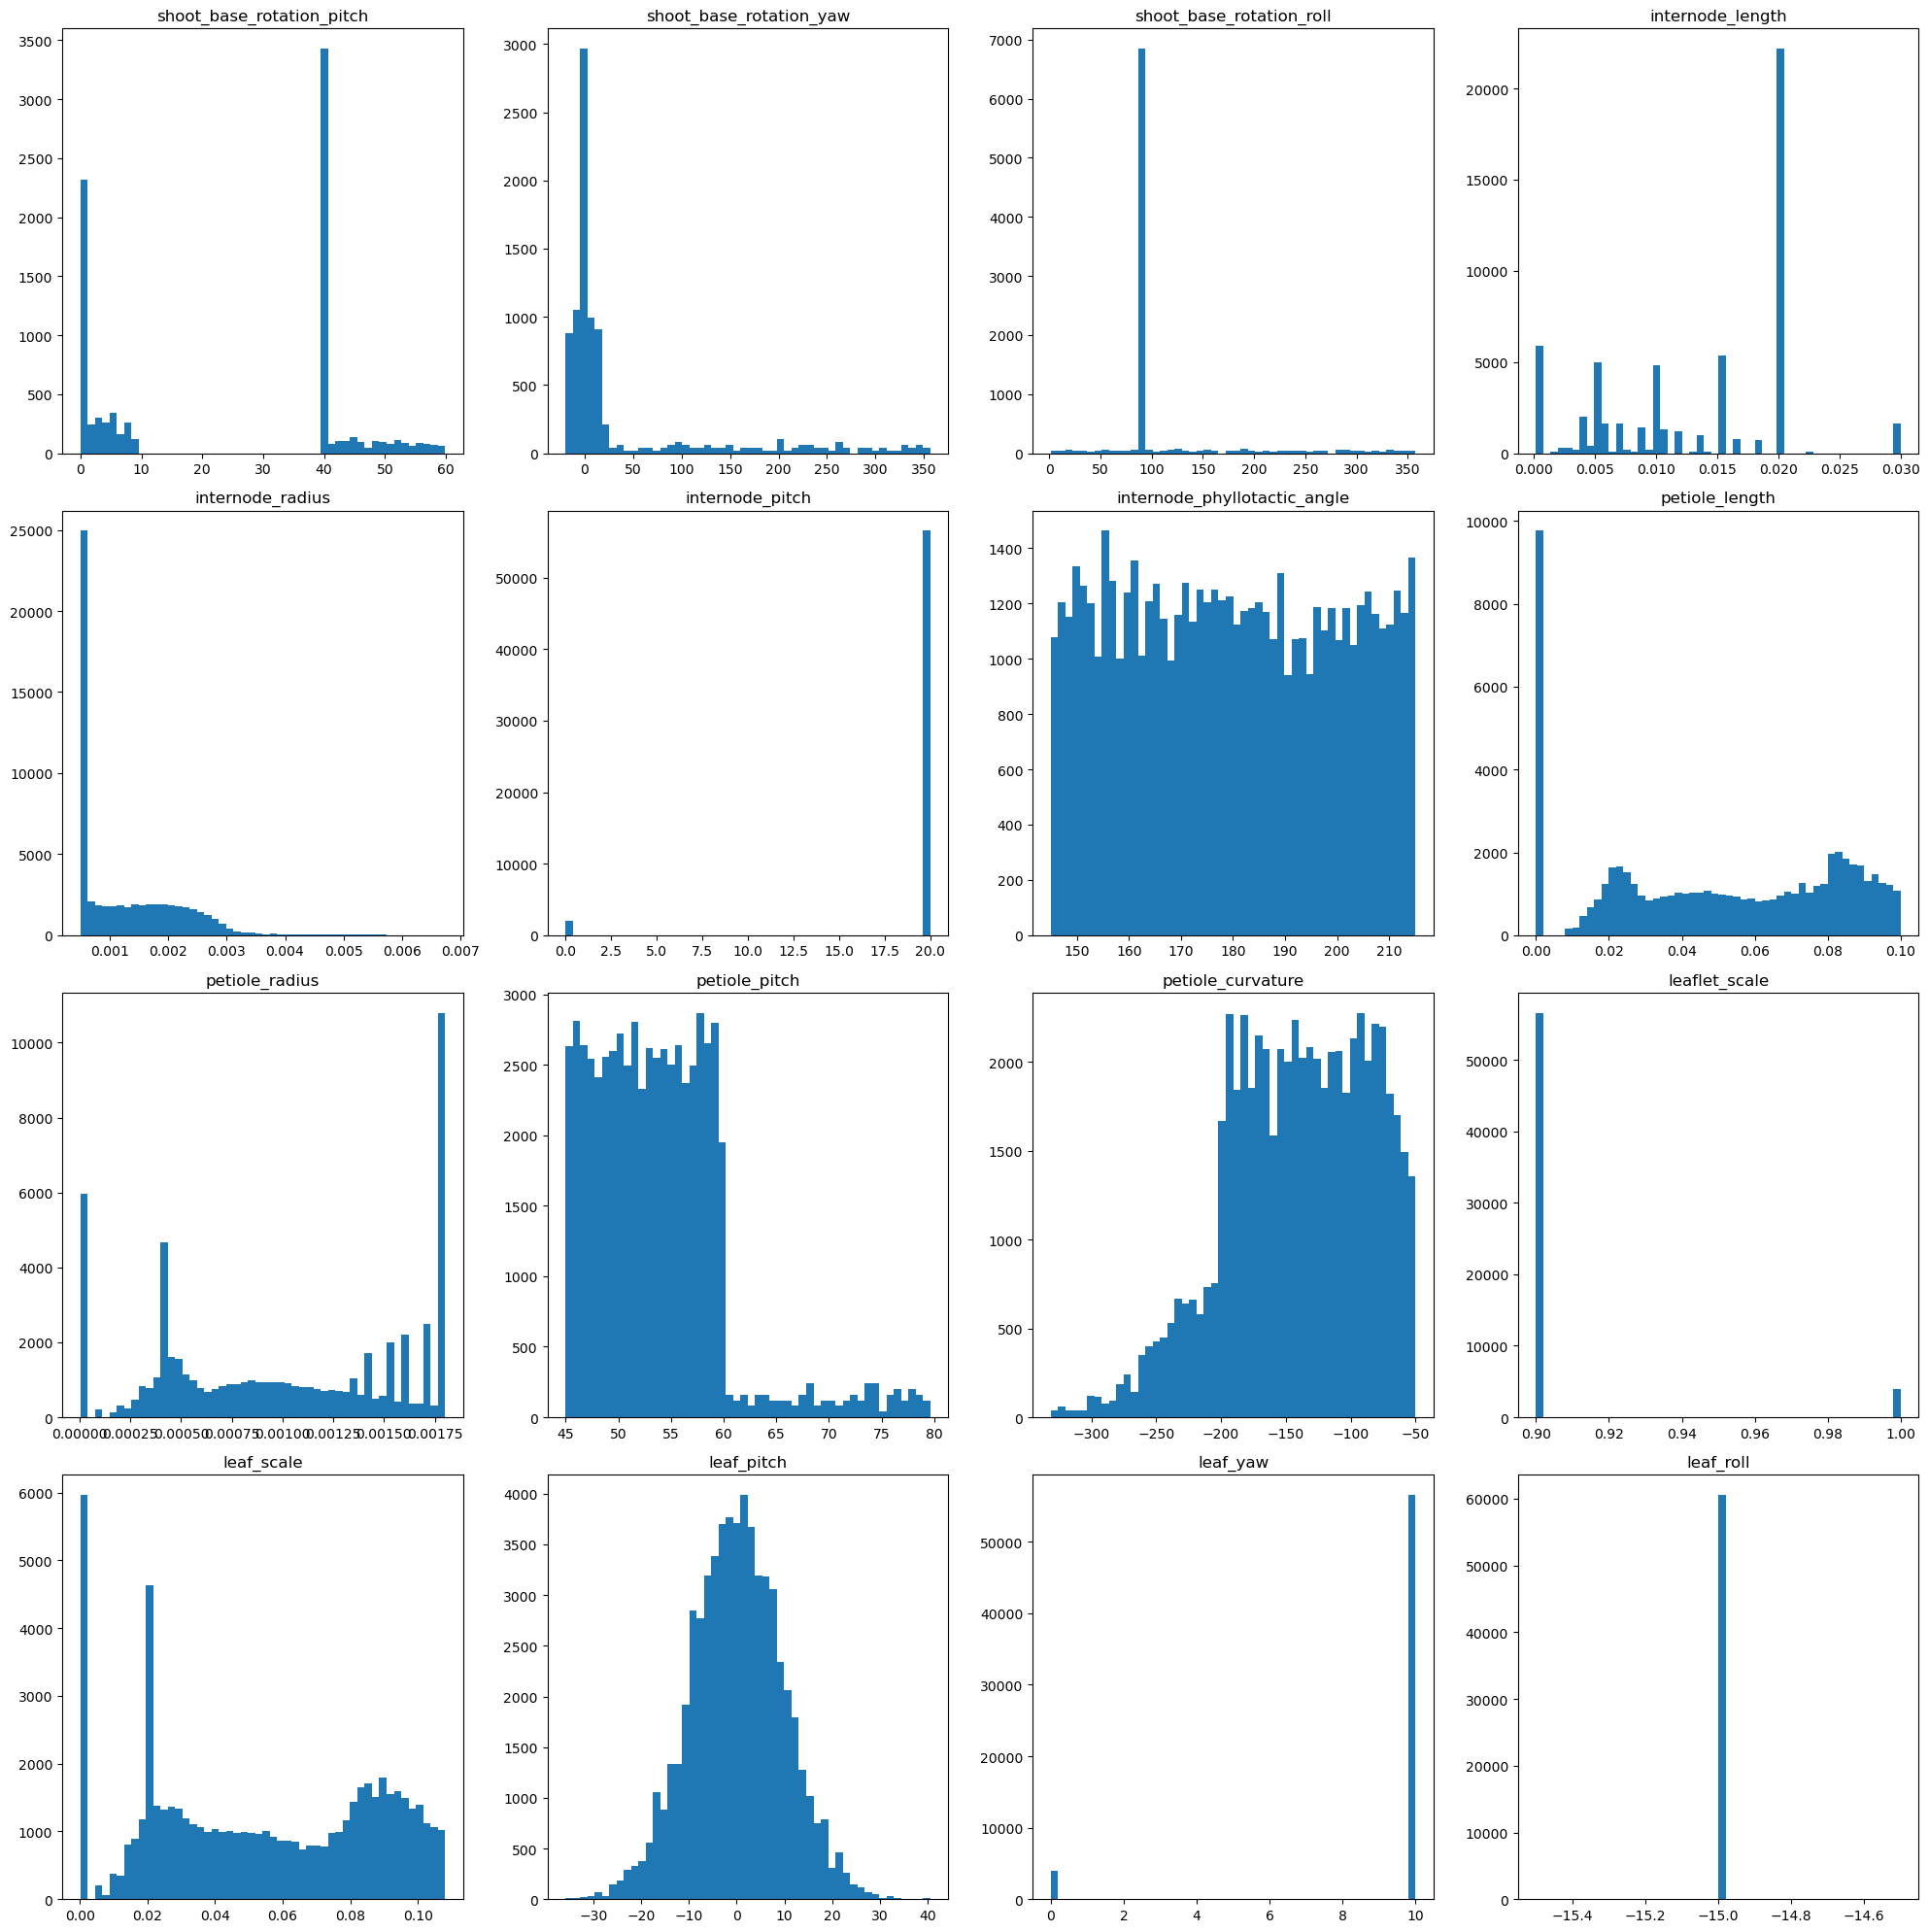

In [6]:
# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

Normalized shoot parameters:
 [[-0.80330637 -0.72062659  0.05741736 -1.         -1.        ]
 [-1.         -0.89696211 -0.50296426 -1.          1.        ]
 [-0.80330637 -0.72062659  0.05741736 -0.89473684 -1.        ]
 ...
 [ 0.33685371 -0.87118549 -0.50296426 -1.          1.        ]
 [-1.         -0.89696211 -0.50296426 -1.          1.        ]
 [ 0.33685371 -0.79306672 -0.50296426 -1.          1.        ]]
Normalized internode parameters:
 [[-0.99328752 -1.         -1.         -0.16803337]
 [-0.87919362 -1.          1.         -0.45461299]
 [-0.48993209 -1.         -1.         -0.16803337]
 ...
 [ 0.32883258 -0.92995163  1.          0.62961799]
 [ 0.00678577 -1.          1.          0.49172834]
 [-0.32887848 -1.          1.          0.03171519]]
Normalized petiole parameters:
 [[-1.         -1.          0.67789565  0.90498544  1.        ]
 [-0.80935543 -0.80400891 -0.62157537 -0.16492554 -1.        ]
 [-1.         -1.          0.67789565  0.90498544  1.        ]
 ...
 [ 0.60133403 

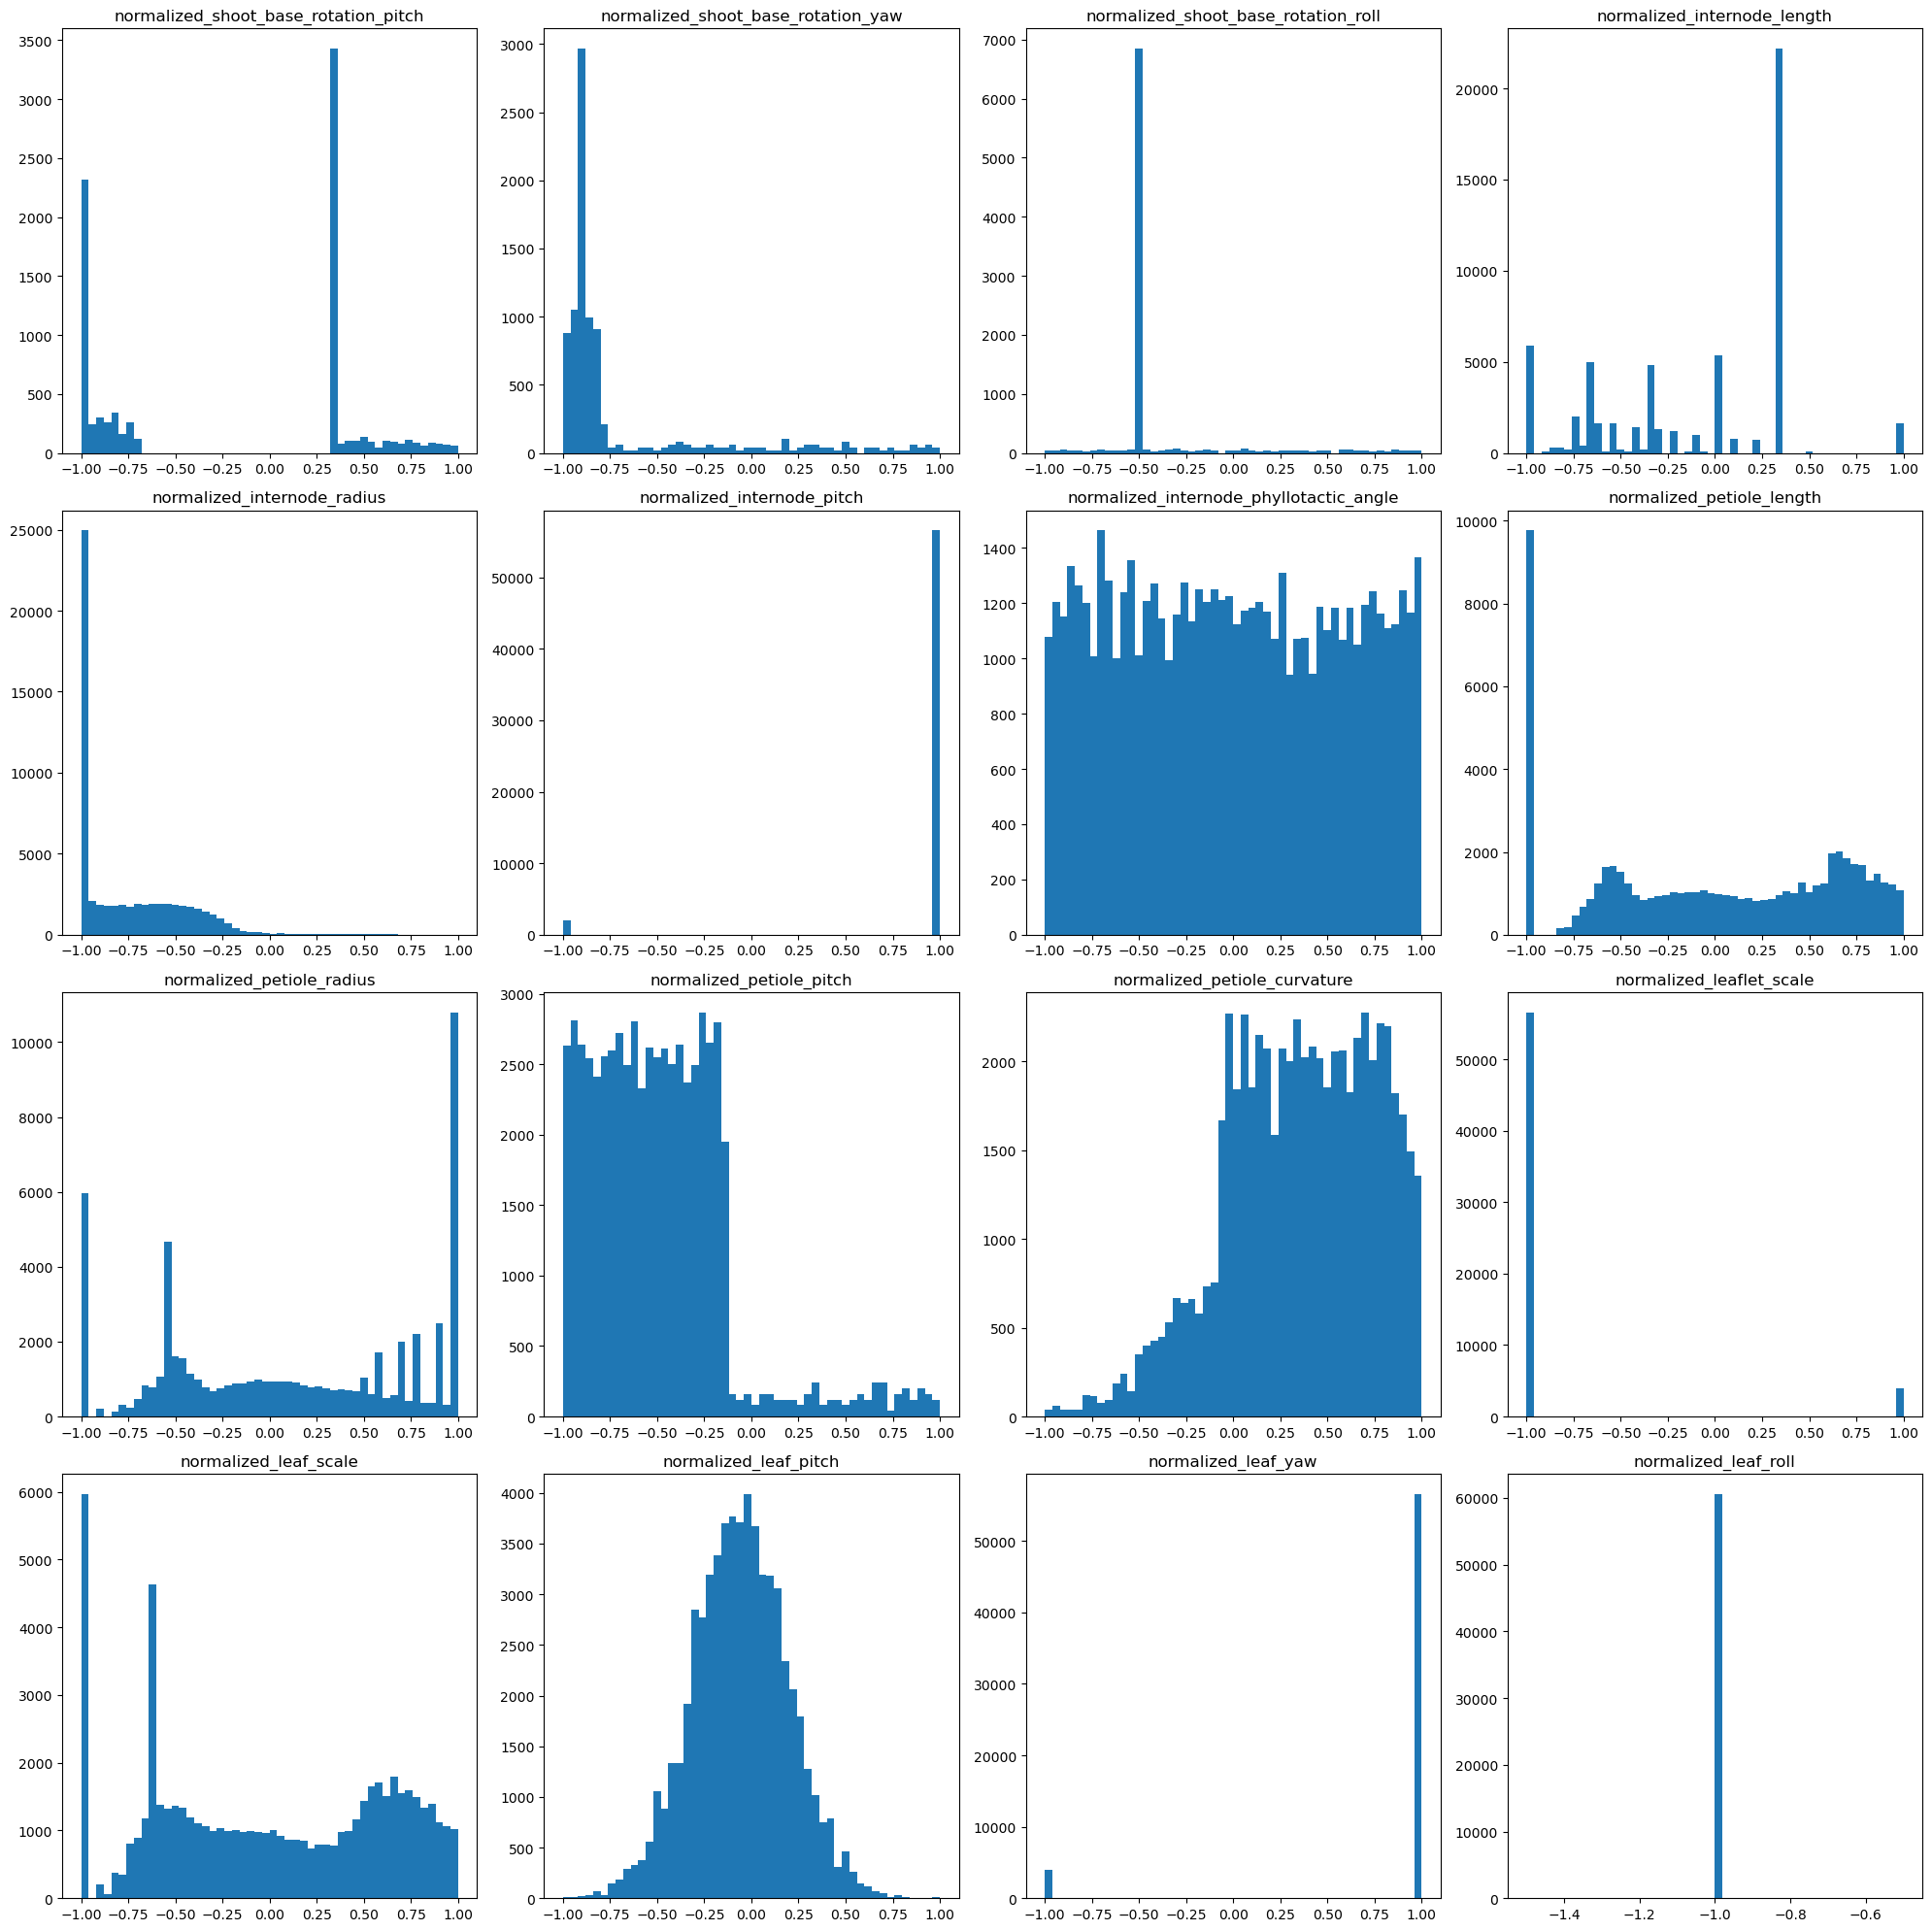

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler with feature range (-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))

# Normalize the parameters
normalized_shoot_params = scaler.fit_transform(all_shoot_params)
normalized_internode_params = scaler.fit_transform(all_internode_params)
normalized_petiole_params = scaler.fit_transform(all_petiole_params)
normalized_leaf_params = scaler.fit_transform(all_leaf_params)

print("Normalized shoot parameters:\n", normalized_shoot_params)
print("Normalized internode parameters:\n", normalized_internode_params)
print("Normalized petiole parameters:\n", normalized_petiole_params)
print("Normalized leaf parameters:\n", normalized_leaf_params)
# Visualize the normalized parameters
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

normalized_params = [
    (normalized_shoot_params[:, 0], "normalized_shoot_base_rotation_pitch"),
    (normalized_shoot_params[:, 1], "normalized_shoot_base_rotation_yaw"),
    (normalized_shoot_params[:, 2], "normalized_shoot_base_rotation_roll"),
    (normalized_internode_params[:, 0], "normalized_internode_length"),
    (normalized_internode_params[:, 1], "normalized_internode_radius"),
    (normalized_internode_params[:, 2], "normalized_internode_pitch"),
    (normalized_internode_params[:, 3], "normalized_internode_phyllotactic_angle"),
    (normalized_petiole_params[:, 0], "normalized_petiole_length"),
    (normalized_petiole_params[:, 1], "normalized_petiole_radius"),
    (normalized_petiole_params[:, 2], "normalized_petiole_pitch"),
    (normalized_petiole_params[:, 3], "normalized_petiole_curvature"),
    (normalized_petiole_params[:, 4], "normalized_leaflet_scale"),
    (normalized_leaf_params[:, 0], "normalized_leaf_scale"),
    (normalized_leaf_params[:, 1], "normalized_leaf_pitch"),
    (normalized_leaf_params[:, 2], "normalized_leaf_yaw"),
    (normalized_leaf_params[:, 3], "normalized_leaf_roll")
]

for ax, (param, title) in zip(axes, normalized_params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [8]:
from plant_tokenizer import token2vec, vec2token
# Convert plant array to plant tokens
total_tokens = None
for array_line in plant_array:
    token = vec2token(array_line)
    token = np.array(token) 
    if total_tokens is None:
        total_tokens = token
    else:
        total_tokens = np.concatenate([total_tokens, token])


# Tokenizer Scale

In [9]:
# Scale tokens except for depth-organ
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler with feature range (-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))

# Normalize the parameters
scaled_params = scaler.fit_transform(total_tokens[:,1:])
total_tokens_scaled = np.concatenate([total_tokens[:,:1],scaled_params],axis=1)

print(total_tokens_scaled)

[[ 0.         -0.80330637 -0.72062659 ... -0.02722045  0.
   1.        ]
 [ 1.         -1.         -0.89696211 ... -0.02722045  0.
   1.        ]
 [ 2.         -1.         -0.89696211 ... -0.02722045  0.
   1.        ]
 ...
 [ 9.         -1.         -0.89696211 ... -0.05707073  1.
  -1.        ]
 [10.         -1.         -0.89696211 ...  0.10414859  0.
  -1.        ]
 [11.         -1.         -0.89696211 ... -0.20357104 -1.
  -1.        ]]


(8827, 5)
(58572, 4)
(60572, 5)
(60572, 4)


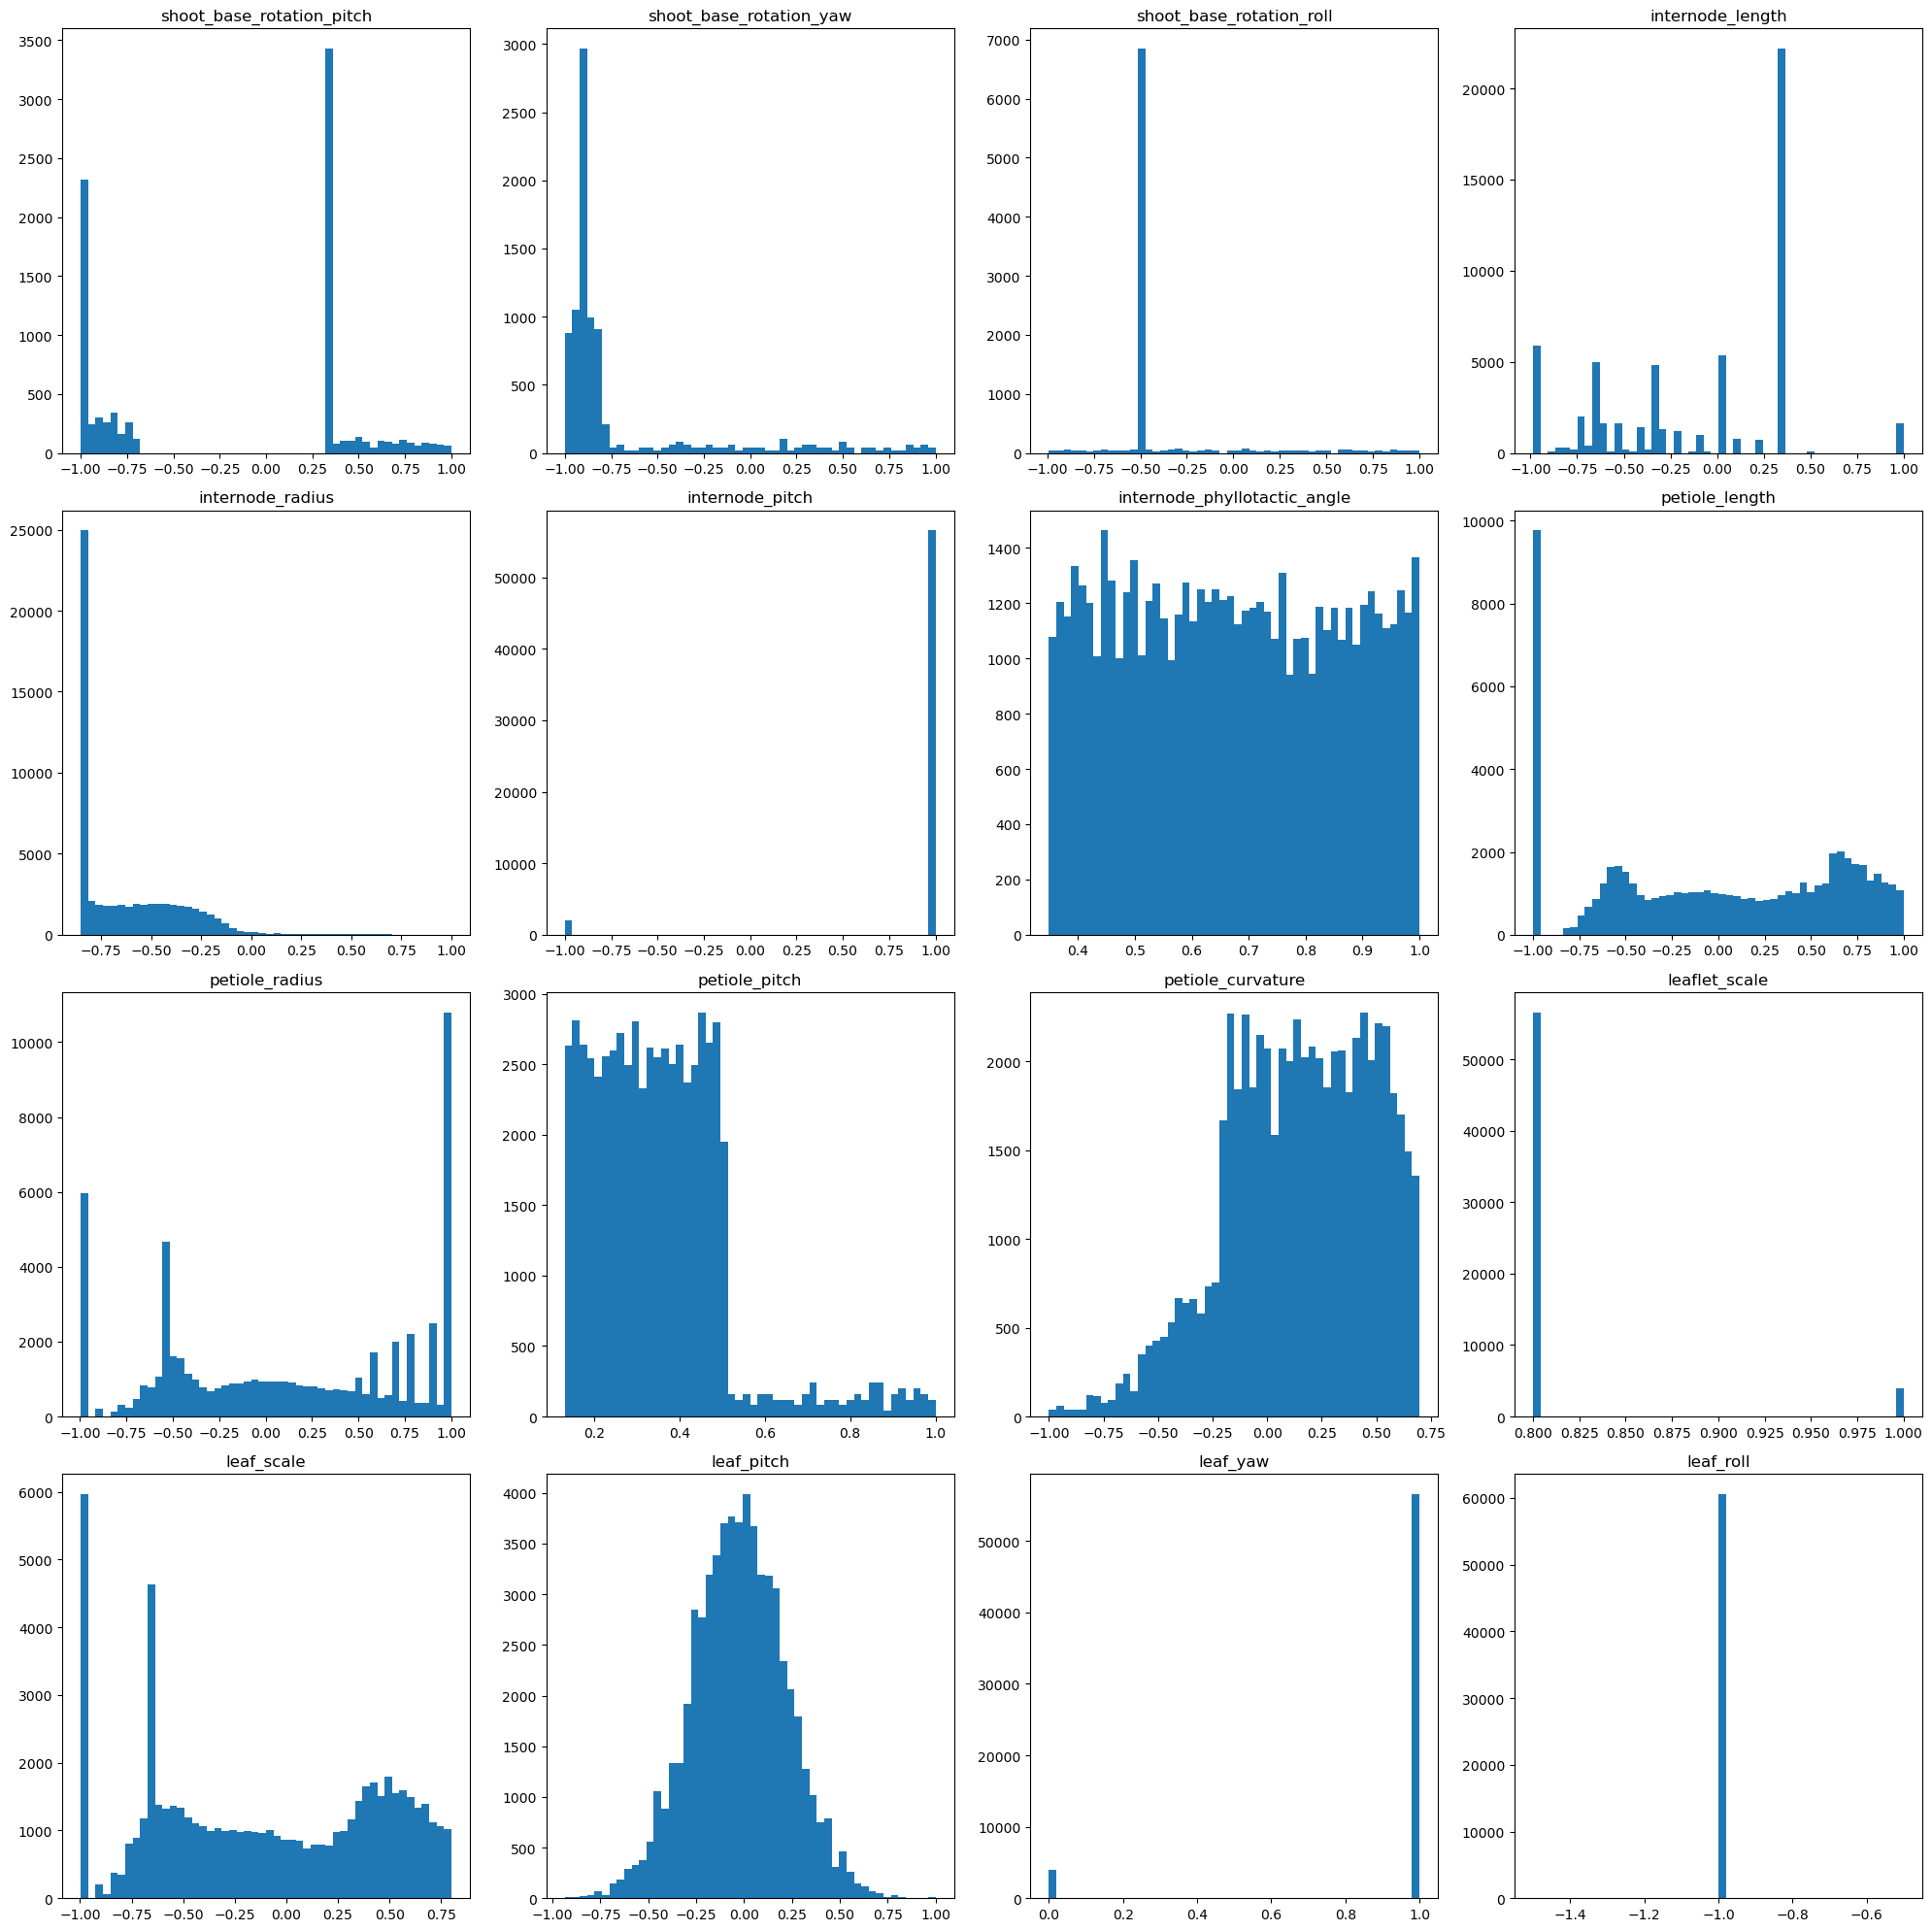

In [10]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in total_tokens_scaled:
    # plant_vectors = scale_vec(plant_vectors)
    depth = token[0] // 6
    organ_type = token[0] % 6
    if organ_type == 0:
        all_shoot_params.append(token[1:6])
    elif organ_type == 1:
        all_internode_params.append(token[6:10])
    elif organ_type == 2:
        all_petiole_params.append(token[10:15])
    elif organ_type == 3:
        all_leaf_params.append(token[15:19])

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)


# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [11]:
# Test inverse scale

# Normalize the parameters
scaled_params = scaler.inverse_transform(total_tokens_scaled[:,1:])
total_tokens_recovered = np.concatenate([total_tokens[:,:1],scaled_params],axis=1)

print(total_tokens_recovered)


[[  0.        5.88527  33.1074  ...   0.        0.        0.     ]
 [  1.        0.        0.      ...   0.        0.        0.     ]
 [  2.        0.        0.      ...   0.        0.        0.     ]
 ...
 [  9.        0.        0.      ...  -1.17661  10.      -15.     ]
 [ 10.        0.        0.      ...   5.17818   0.      -15.     ]
 [ 11.        0.        0.      ...  -6.95122 -10.      -15.     ]]


(8827, 5)
(58572, 4)
(60572, 5)
(60572, 4)


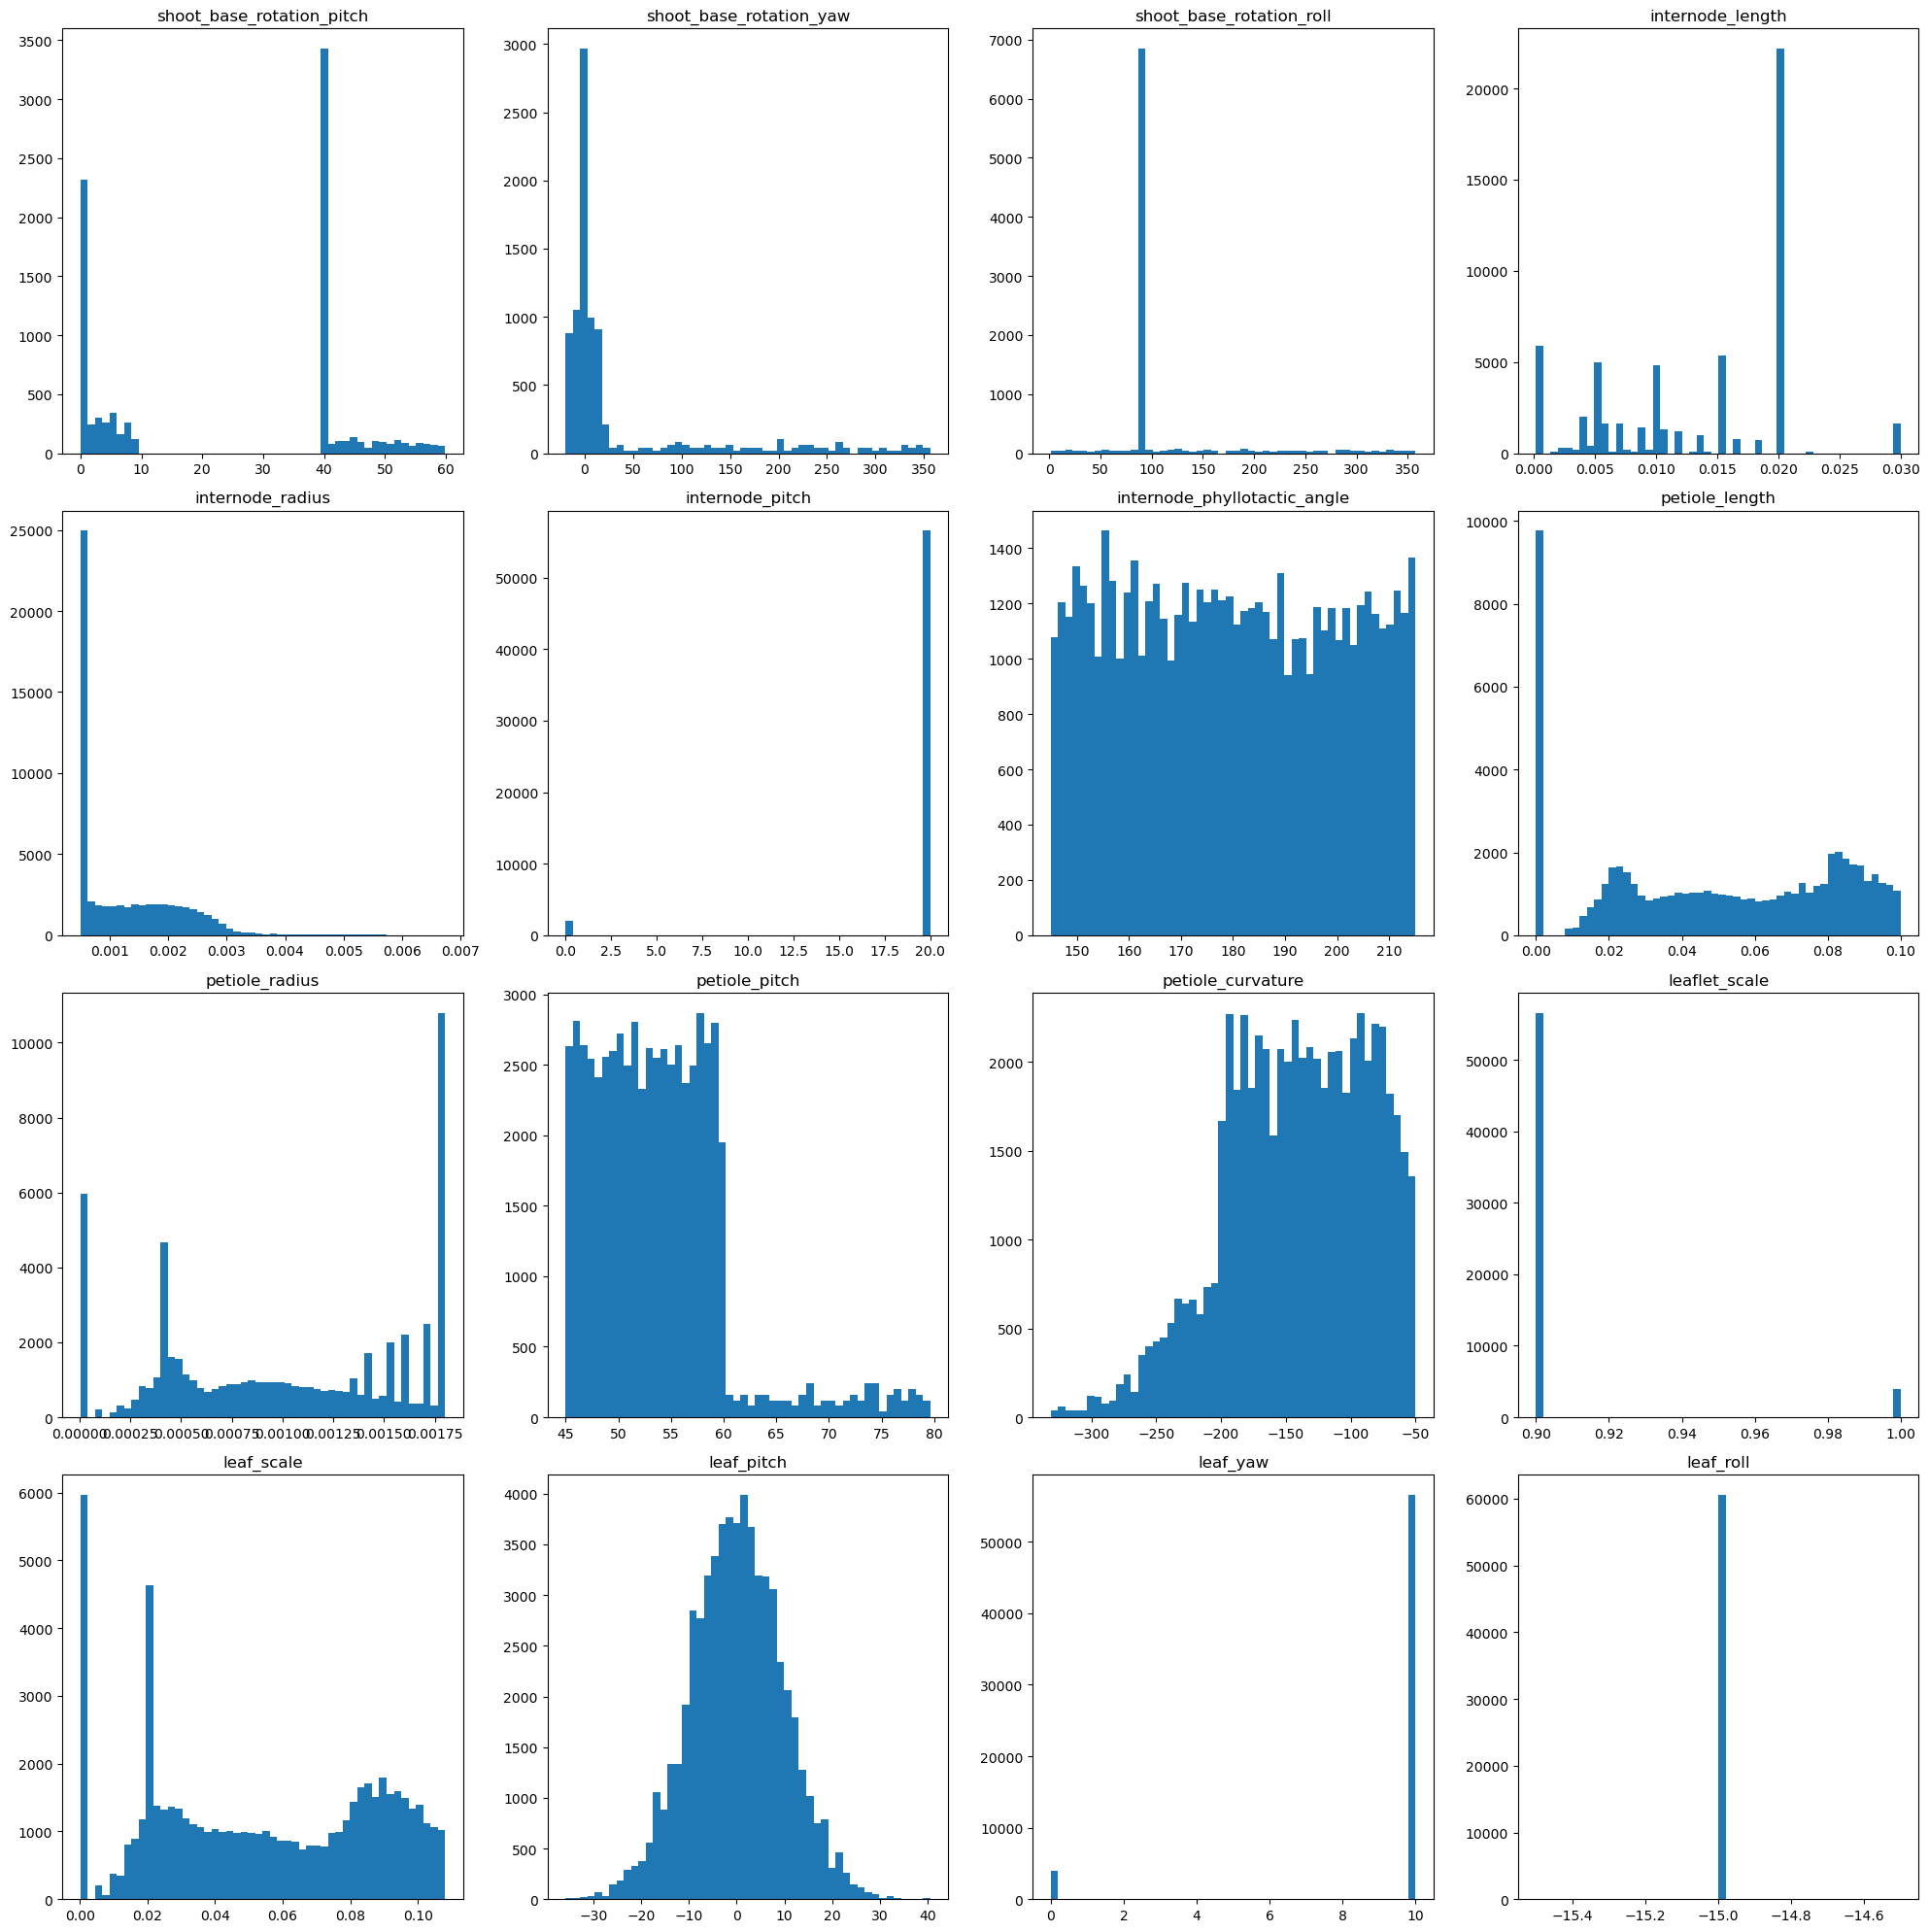

In [12]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in total_tokens_recovered:
    # plant_vectors = scale_vec(plant_vectors)
    depth = token[0] // 6
    organ_type = token[0] % 6
    if organ_type == 0:
        all_shoot_params.append(token[1:6])
    elif organ_type == 1:
        all_internode_params.append(token[6:10])
    elif organ_type == 2:
        all_petiole_params.append(token[10:15])
    elif organ_type == 3:
        all_leaf_params.append(token[15:19])

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)


# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [13]:
import joblib
# Save scaler to file
# Save the scaler to a file
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [14]:
# 스케일러 요약 정보 출력
def print_scaler_summary(scaler):
    print("MinMaxScaler Summary:")
    print(f"Data Min: {scaler.data_min_}")
    print(f"Data Max: {scaler.data_max_}")
    print(f"Scale: {scaler.scale_}")
    print(f"Min: {scaler.min_}")

print_scaler_summary(scaler)

MinMaxScaler Summary:
Data Min: [   0.      -19.3456    0.        0.        0.        0.        0.
    0.        0.        0.        0.        0.     -331.326     0.
    0.      -38.3441  -10.      -15.    ]
Data Max: [5.98420e+01 3.56159e+02 3.57383e+02 1.90000e+01 3.00000e+00 3.00000e-02
 6.73295e-03 2.00000e+01 2.15000e+02 9.99985e-02 1.80000e-03 7.95954e+01
 0.00000e+00 1.00000e+00 1.20000e-01 4.04900e+01 1.00000e+01 0.00000e+00]
Scale: [3.34213429e-02 5.32616644e-03 5.59623709e-03 1.05263158e-01
 6.66666667e-01 6.66666667e+01 2.97046614e+02 1.00000000e-01
 9.30232558e-03 2.00003000e+01 1.11111111e+03 2.51270802e-02
 6.03635091e-03 2.00000000e+00 1.66666667e+01 2.53697321e-02
 1.00000000e-01 1.33333333e-01]
Min: [-1.         -0.89696211 -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
  1.         -1.         -1.         -0.02722045  0.          1.        ]


In [15]:
import torch
import torch.nn as nn

class MinMaxScalerTorch(nn.Module):
    def __init__(self, feature_range=(-1, 1)):
        super(MinMaxScalerTorch, self).__init__()
        self.min, self.max = feature_range
        self.data_min_ = torch.tensor([0, -19.3456, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -331.326, 0, 0, -38.3441, -10, -15], dtype=torch.float32, requires_grad=False)
        self.data_max_ = torch.tensor([59.842, 356.159, 357.383, 19, 3, 0.03, 0.00673295, 20, 215, 0.0999985, 0.0018, 79.5954, 0, 1, 0.12, 40.49, 10, 0], dtype=torch.float32, requires_grad=False)
        self.scale_ = torch.tensor([3.34213429e-02, 5.32616644e-03, 5.59623709e-03, 1.05263158e-01,
                                    6.66666667e-01, 6.66666667e+01, 2.97046614e+02, 1.00000000e-01,
                                    9.30232558e-03, 2.00003000e+01, 1.11111111e+03, 2.51270802e-02,
                                    6.03635091e-03, 2.00000000e+00, 1.66666667e+01, 2.53697321e-02,
                                    1.00000000e-01, 1.33333333e-01], dtype=torch.float32, requires_grad=False)
        self.min_ = torch.tensor([-1., -0.89696211, -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
                                  1., -1., -1., -0.02722045, 0., 1.], dtype=torch.float32, requires_grad=False)

        # 1D Convolution layer for scaling and inverse scaling
        self.conv = nn.Conv1d(in_channels=18, out_channels=18, kernel_size=1, bias=True)
        self.inv_conv = nn.Conv1d(in_channels=18, out_channels=18, kernel_size=1, bias=True)

        # Initialize convolution weights and bias
        self.conv.weight.data = torch.diag(self.scale_).view(18, 18, 1)
        self.conv.bias.data = self.min_

        # Initialize inverse convolution weights and bias
        self.inv_conv.weight.data = torch.diag(1/self.scale_).view(18, 18, 1)
        self.inv_conv.bias.data = -self.min_ / self.scale_

    def fit(self, data):
        self.data_min_ = data.min(0, keepdim=True)[0]
        self.data_max_ = data.max(0, keepdim=True)[0]
        self.scale_ = (self.max - self.min) / (self.data_max_ - self.data_min_)
        self.min_ = self.min - self.data_min_ * self.scale_

        # Update convolution weights and bias
        self.conv.weight.data = torch.diag(self.scale_).view(18, 18, 1)
        self.conv.bias.data = self.min_

        # Update inverse convolution weights and bias
        self.inv_conv.weight.data = (1 / self.scale_).view(1, 18, 1)
        self.inv_conv.bias.data = -self.min_ / self.scale_

    def transform(self, data):
        with torch.no_grad():
            data = data.permute(0, 2, 1)  # (batch_size, seq_len, num_features) -> (batch_size, num_features, seq_len)
            transformed = self.conv(data)
        return transformed.permute(0, 2, 1)  # (batch_size, num_features, seq_len) -> (batch_size, seq_len, num_features)

    def inverse_transform(self, data):
        with torch.no_grad():
            data = data.permute(0, 2, 1)  # (batch_size, seq_len, num_features) -> (batch_size, num_features, seq_len)
            inverse_transformed = self.inv_conv(data)
        return inverse_transformed.permute(0, 2, 1)  # (batch_size, num_features, seq_len) -> (batch_size, seq_len, num_features)

In [16]:
# Test inverse scale
scaler = MinMaxScalerTorch()
# Normalize the parameters
total_tokens_scaled_tensor = torch.tensor(total_tokens_scaled[:,1:],dtype=torch.float).view(-1,1,18)
scaled_params_tensor = scaler.inverse_transform(total_tokens_scaled_tensor)
scaled_params = scaled_params_tensor.numpy().squeeze()
total_tokens_recovered = np.concatenate([total_tokens[:,:1],scaled_params],axis=1)

print(total_tokens_recovered)


[[ 0.00000000e+00  5.88526917e+00  3.31074066e+01 ... -1.19209290e-07
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.19209290e-07
   0.00000000e+00  0.00000000e+00]
 [ 2.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.19209290e-07
   0.00000000e+00  0.00000000e+00]
 ...
 [ 9.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.17661023e+00
   1.00000000e+01 -1.49999990e+01]
 [ 1.00000000e+01  0.00000000e+00  0.00000000e+00 ...  5.17817974e+00
   0.00000000e+00 -1.49999990e+01]
 [ 1.10000000e+01  0.00000000e+00  0.00000000e+00 ... -6.95122004e+00
  -1.00000000e+01 -1.49999990e+01]]


(8827, 5)
(58572, 4)
(60572, 5)
(60572, 4)


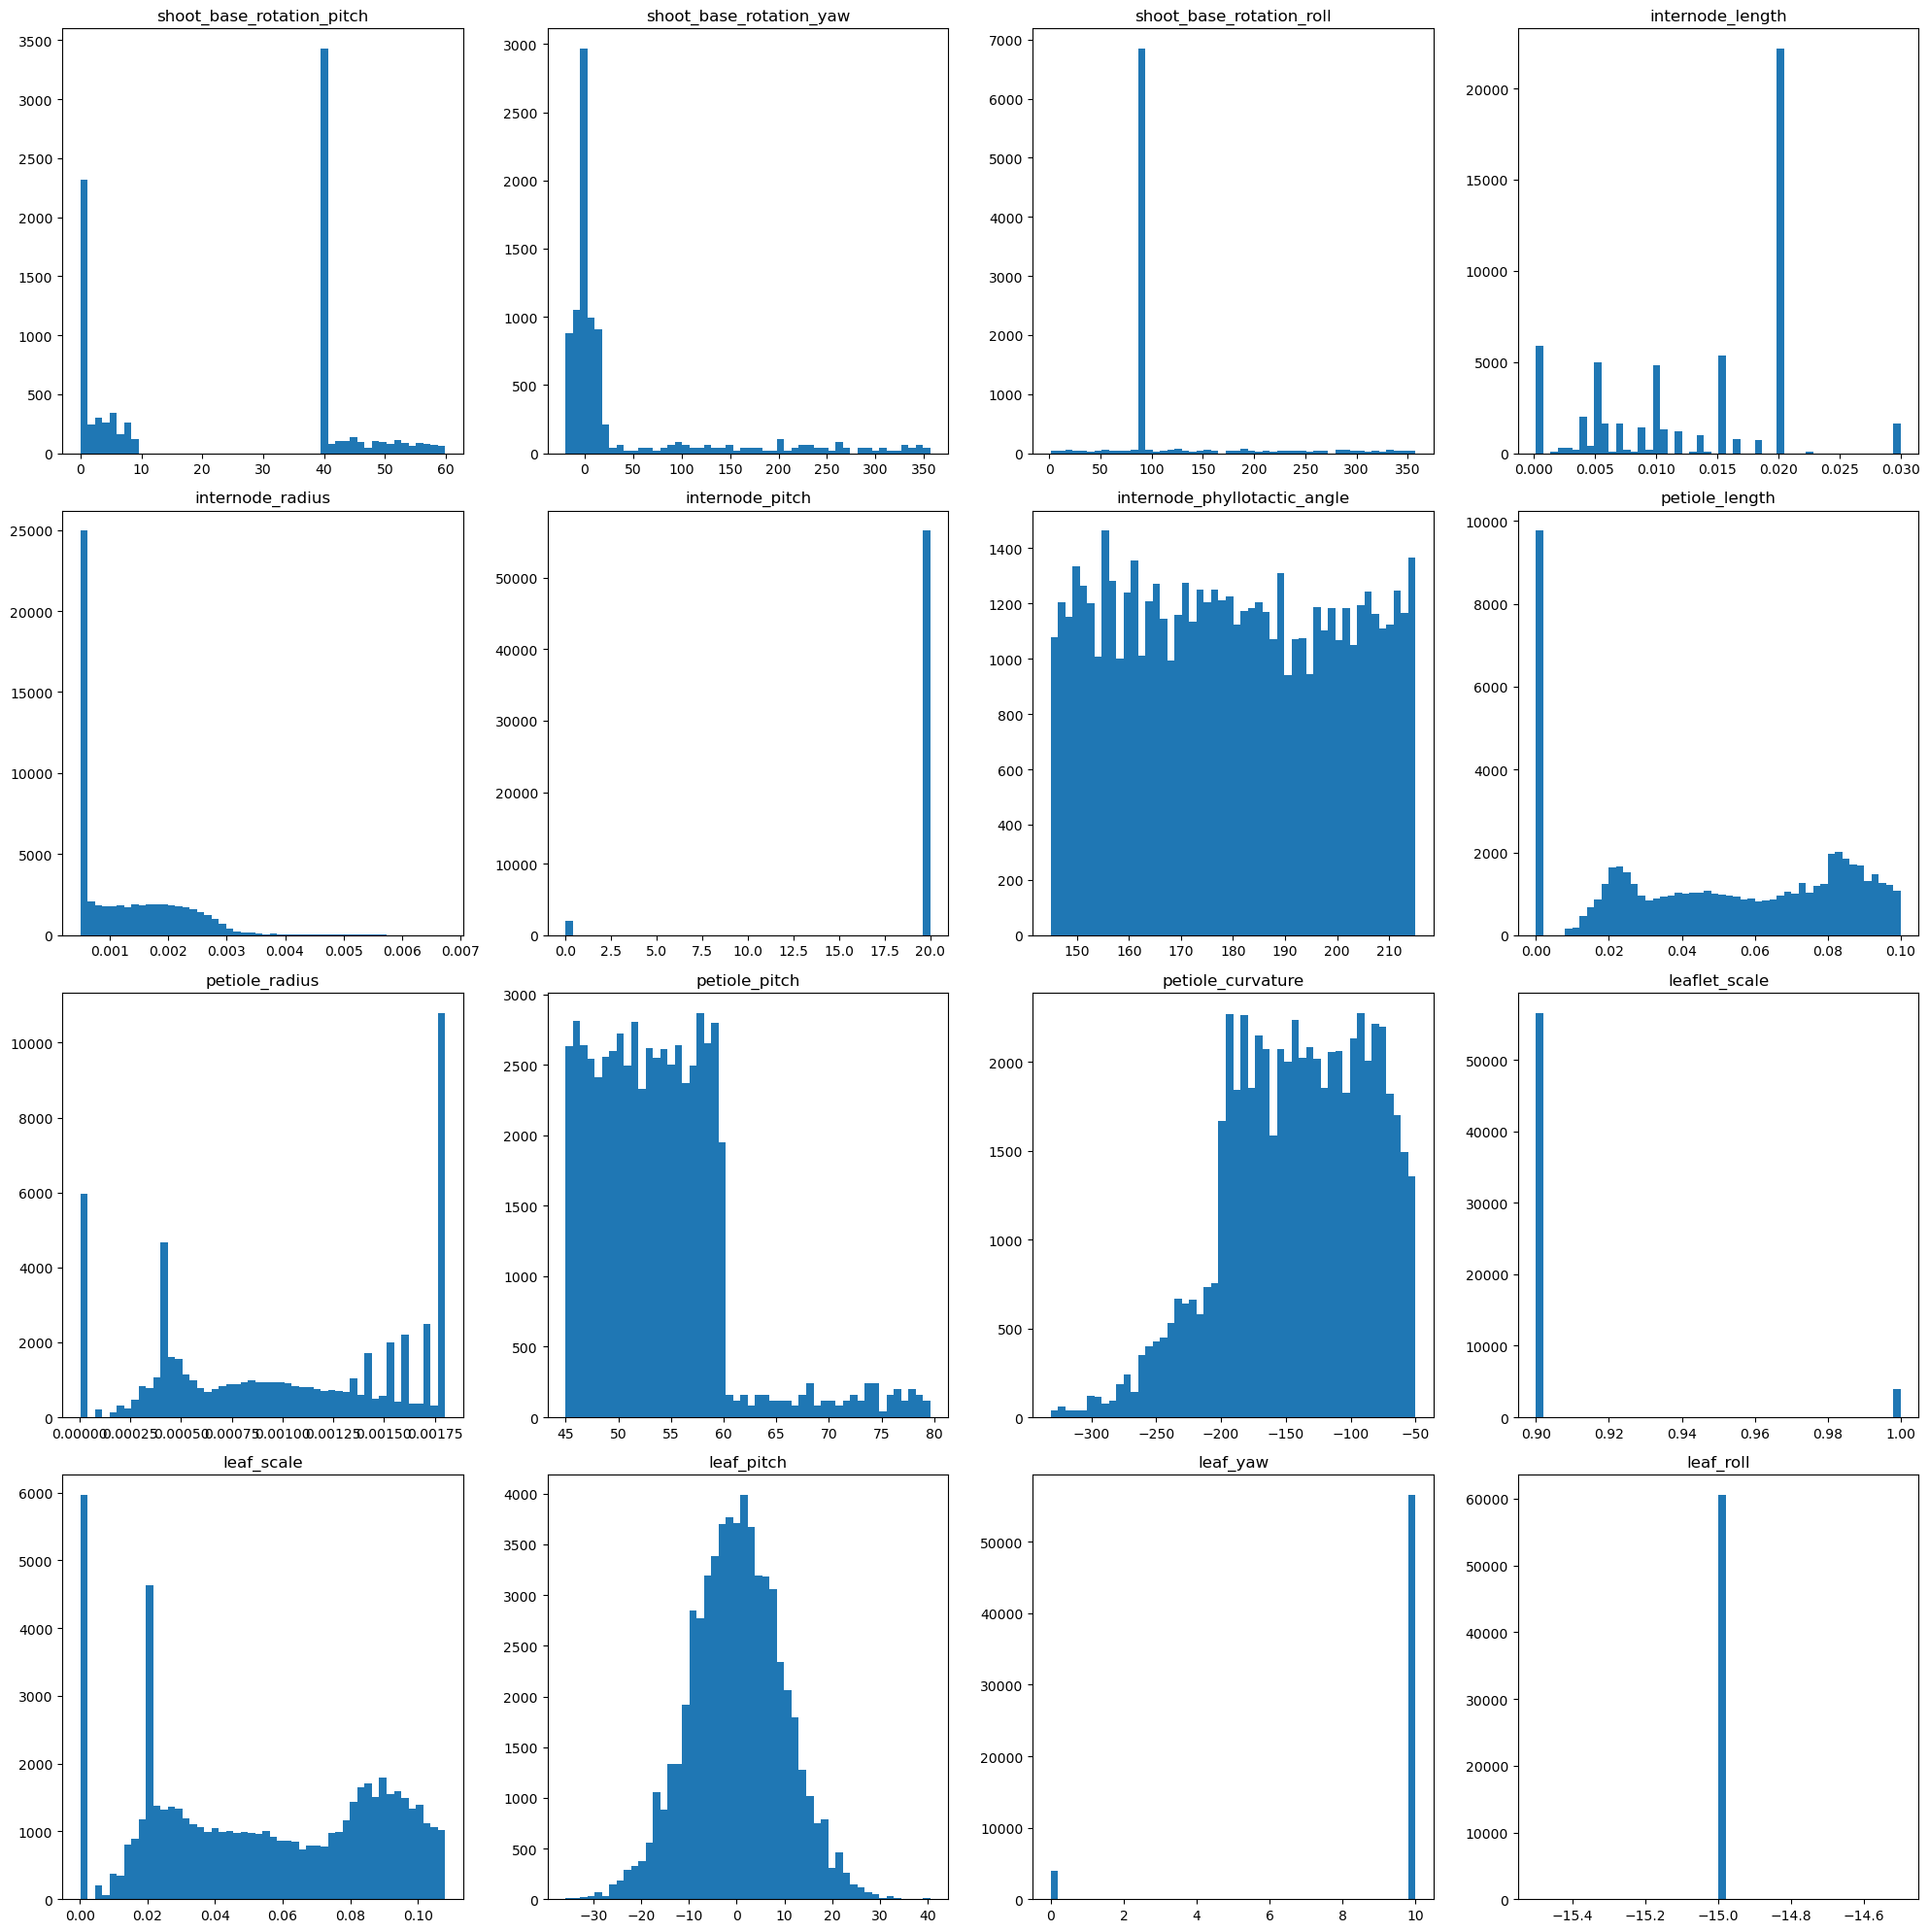

In [17]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in total_tokens_recovered:
    # plant_vectors = scale_vec(plant_vectors)
    depth = token[0] // 6
    organ_type = token[0] % 6
    if organ_type == 0:
        all_shoot_params.append(token[1:6])
    elif organ_type == 1:
        all_internode_params.append(token[6:10])
    elif organ_type == 2:
        all_petiole_params.append(token[10:15])
    elif organ_type == 3:
        all_leaf_params.append(token[15:19])

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)


# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

(array([100., 220., 160.,  80., 200., 100., 120., 140., 180., 160.,  80.,
         80., 120., 140., 120.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,  27.,  58.,  31.,  54.,  44.,  78.,  26.,  79.,  58.,  55.,
         36.,  18.,  26.,  32.,  71.,  62.,  30.,  48.,  33.,  47.,  62.,
         35.,  54.,  25.,  41.,  54.,  29.,  38.,  38.,  35.,  37.,  43.,
         23.]),
 array([1.70372000e-02, 6.15286828e-01, 1.21353646e+00, 1.81178608e+00,
        2.41003571e+00, 3.00828534e+00, 3.60653497e+00, 4.20478460e+00,
        4.80303422e+00, 5.40128385e+00, 5.99953348e+00, 6.59778311e+00,
        7.19603274e+00, 7.79428236e+00, 8.39253199e+00, 8.99078162e+00,
        9.58903125e+00, 1.0187

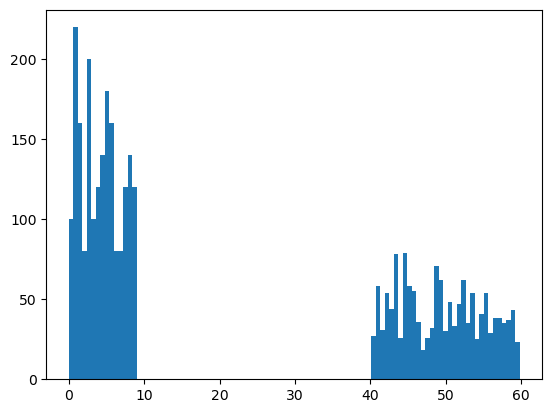

In [18]:
# Fit each params to bins. 100 bins?
len(total_tokens)



# plt.plot(total_tokens[:,1])
# plt.hist(total_tokens[:,1], bins=100)

filtered = [x for x in total_tokens[:,1] if x not in [0,40]]
plt.hist(filtered, bins=100)

In [19]:
from sklearn.cluster import MiniBatchKMeans, KMeans
# Make a custom kmeans
predetermined_centers = np.concatenate([
                                        np.linspace(-360, 360, 18+1), # angles
                                        np.array([0, 10, -10, 15, -15, 20, 40, 90]), # Some special angles
                                        np.array([0.9, 1.0]), # Some special float values
                                        np.array([0, 1, 3]), # integer values
                                        np.linspace(0, 1.0, 11),
                                        np.linspace(0, 0.1, 11),
                                        np.linspace(0, 0.01, 11), # float values for lenghts
                                        np.linspace(0, 0.001, 11), # float values for lenghts
                                        ])
predetermined_centers = np.unique(predetermined_centers).reshape(-1, 1)

n_clusters = predetermined_centers.shape[0]
print("n_clusters: ", n_clusters)
kmeans = KMeans(n_clusters=n_clusters, init=predetermined_centers, n_init=1, max_iter=1)
kmeans.fit(predetermined_centers)
kmeans.cluster_centers_ = predetermined_centers

print(kmeans.cluster_centers_)

n_clusters:  63
[[-3.6e+02]
 [-3.2e+02]
 [-2.8e+02]
 [-2.4e+02]
 [-2.0e+02]
 [-1.6e+02]
 [-1.2e+02]
 [-8.0e+01]
 [-4.0e+01]
 [-1.5e+01]
 [-1.0e+01]
 [ 0.0e+00]
 [ 1.0e-04]
 [ 2.0e-04]
 [ 3.0e-04]
 [ 4.0e-04]
 [ 5.0e-04]
 [ 6.0e-04]
 [ 7.0e-04]
 [ 8.0e-04]
 [ 9.0e-04]
 [ 1.0e-03]
 [ 2.0e-03]
 [ 3.0e-03]
 [ 4.0e-03]
 [ 5.0e-03]
 [ 6.0e-03]
 [ 7.0e-03]
 [ 8.0e-03]
 [ 9.0e-03]
 [ 1.0e-02]
 [ 2.0e-02]
 [ 3.0e-02]
 [ 4.0e-02]
 [ 5.0e-02]
 [ 6.0e-02]
 [ 7.0e-02]
 [ 8.0e-02]
 [ 9.0e-02]
 [ 1.0e-01]
 [ 2.0e-01]
 [ 3.0e-01]
 [ 4.0e-01]
 [ 5.0e-01]
 [ 6.0e-01]
 [ 7.0e-01]
 [ 8.0e-01]
 [ 9.0e-01]
 [ 1.0e+00]
 [ 3.0e+00]
 [ 1.0e+01]
 [ 1.5e+01]
 [ 2.0e+01]
 [ 4.0e+01]
 [ 8.0e+01]
 [ 9.0e+01]
 [ 1.2e+02]
 [ 1.6e+02]
 [ 2.0e+02]
 [ 2.4e+02]
 [ 2.8e+02]
 [ 3.2e+02]
 [ 3.6e+02]]


In [30]:
predetermined_centers = torch.tensor([
            0, 10, -10, 15, -15, 20, 40, 90,  # Some special angles
            *torch.linspace(-360, 360, 18+1),  # angles
            0.9, 1.0,  # Some special float values
            1, 3,  # Some special integer values
            *torch.linspace(0, 1.0, 11),
            *torch.linspace(0, 0.1, 11),
            *torch.linspace(0, 0.01, 11),  # float values for lengths
            *torch.linspace(0, 0.001, 11)  # float values for lengths
        ]).unique().reshape(-1, 1)
print(predetermined_centers.shape)

KeyboardInterrupt: 

In [32]:
predetermined_centers = np.unique(np.concatenate([
            np.array([0, 10, -10, 15, -15, 20, 40, 90]),  # Some special angles
            np.linspace(-360, 360, 18+1),  # angles
            np.array([0.9, 1.0]),  # Some special float values
            np.array([1,  3]),  # Some special integer values
            np.linspace(0, 1.0, 11),
            np.linspace(0, 0.1, 11),
            np.linspace(0, 0.01, 11),  # float values for lengths
            np.linspace(0, 0.001, 11)  # float values for lengths
        ])).reshape(-1, 1)
print(predetermined_centers.shape)

(63, 1)


In [20]:
# Calculate the quantized params
quantized_shoot_params = kmeans.predict(all_shoot_params.reshape(-1, 1))
quantized_internode_params = kmeans.predict(all_internode_params.reshape(-1, 1))
quantized_petiole_params = kmeans.predict(all_petiole_params.reshape(-1, 1))
quantized_leaf_params = kmeans.predict(all_leaf_params.reshape(-1, 1))

# Convert back to original params
original_shoot_params = kmeans.cluster_centers_[quantized_shoot_params].reshape(all_shoot_params.shape)
original_internode_params = kmeans.cluster_centers_[quantized_internode_params].reshape(all_internode_params.shape)
original_petiole_params = kmeans.cluster_centers_[quantized_petiole_params].reshape(all_petiole_params.shape)
original_leaf_params = kmeans.cluster_centers_[quantized_leaf_params].reshape(all_leaf_params.shape)

# Calculate the error
error_shoot = np.mean(np.abs(all_shoot_params - original_shoot_params))
error_internode = np.mean(np.abs(all_internode_params - original_internode_params))
error_petiole = np.mean(np.abs(all_petiole_params - original_petiole_params))
error_leaf = np.mean(np.abs(all_leaf_params - original_leaf_params))

print("Error shoot: ", error_shoot)
print("Error internode: ", error_internode)
print("Error petiole: ", error_petiole)
print("Error leaf: ", error_leaf)

Error shoot:  1.400255052197678
Error internode:  2.248416201746588
Error petiole:  4.506711247072081
Error leaf:  0.4791709028579299


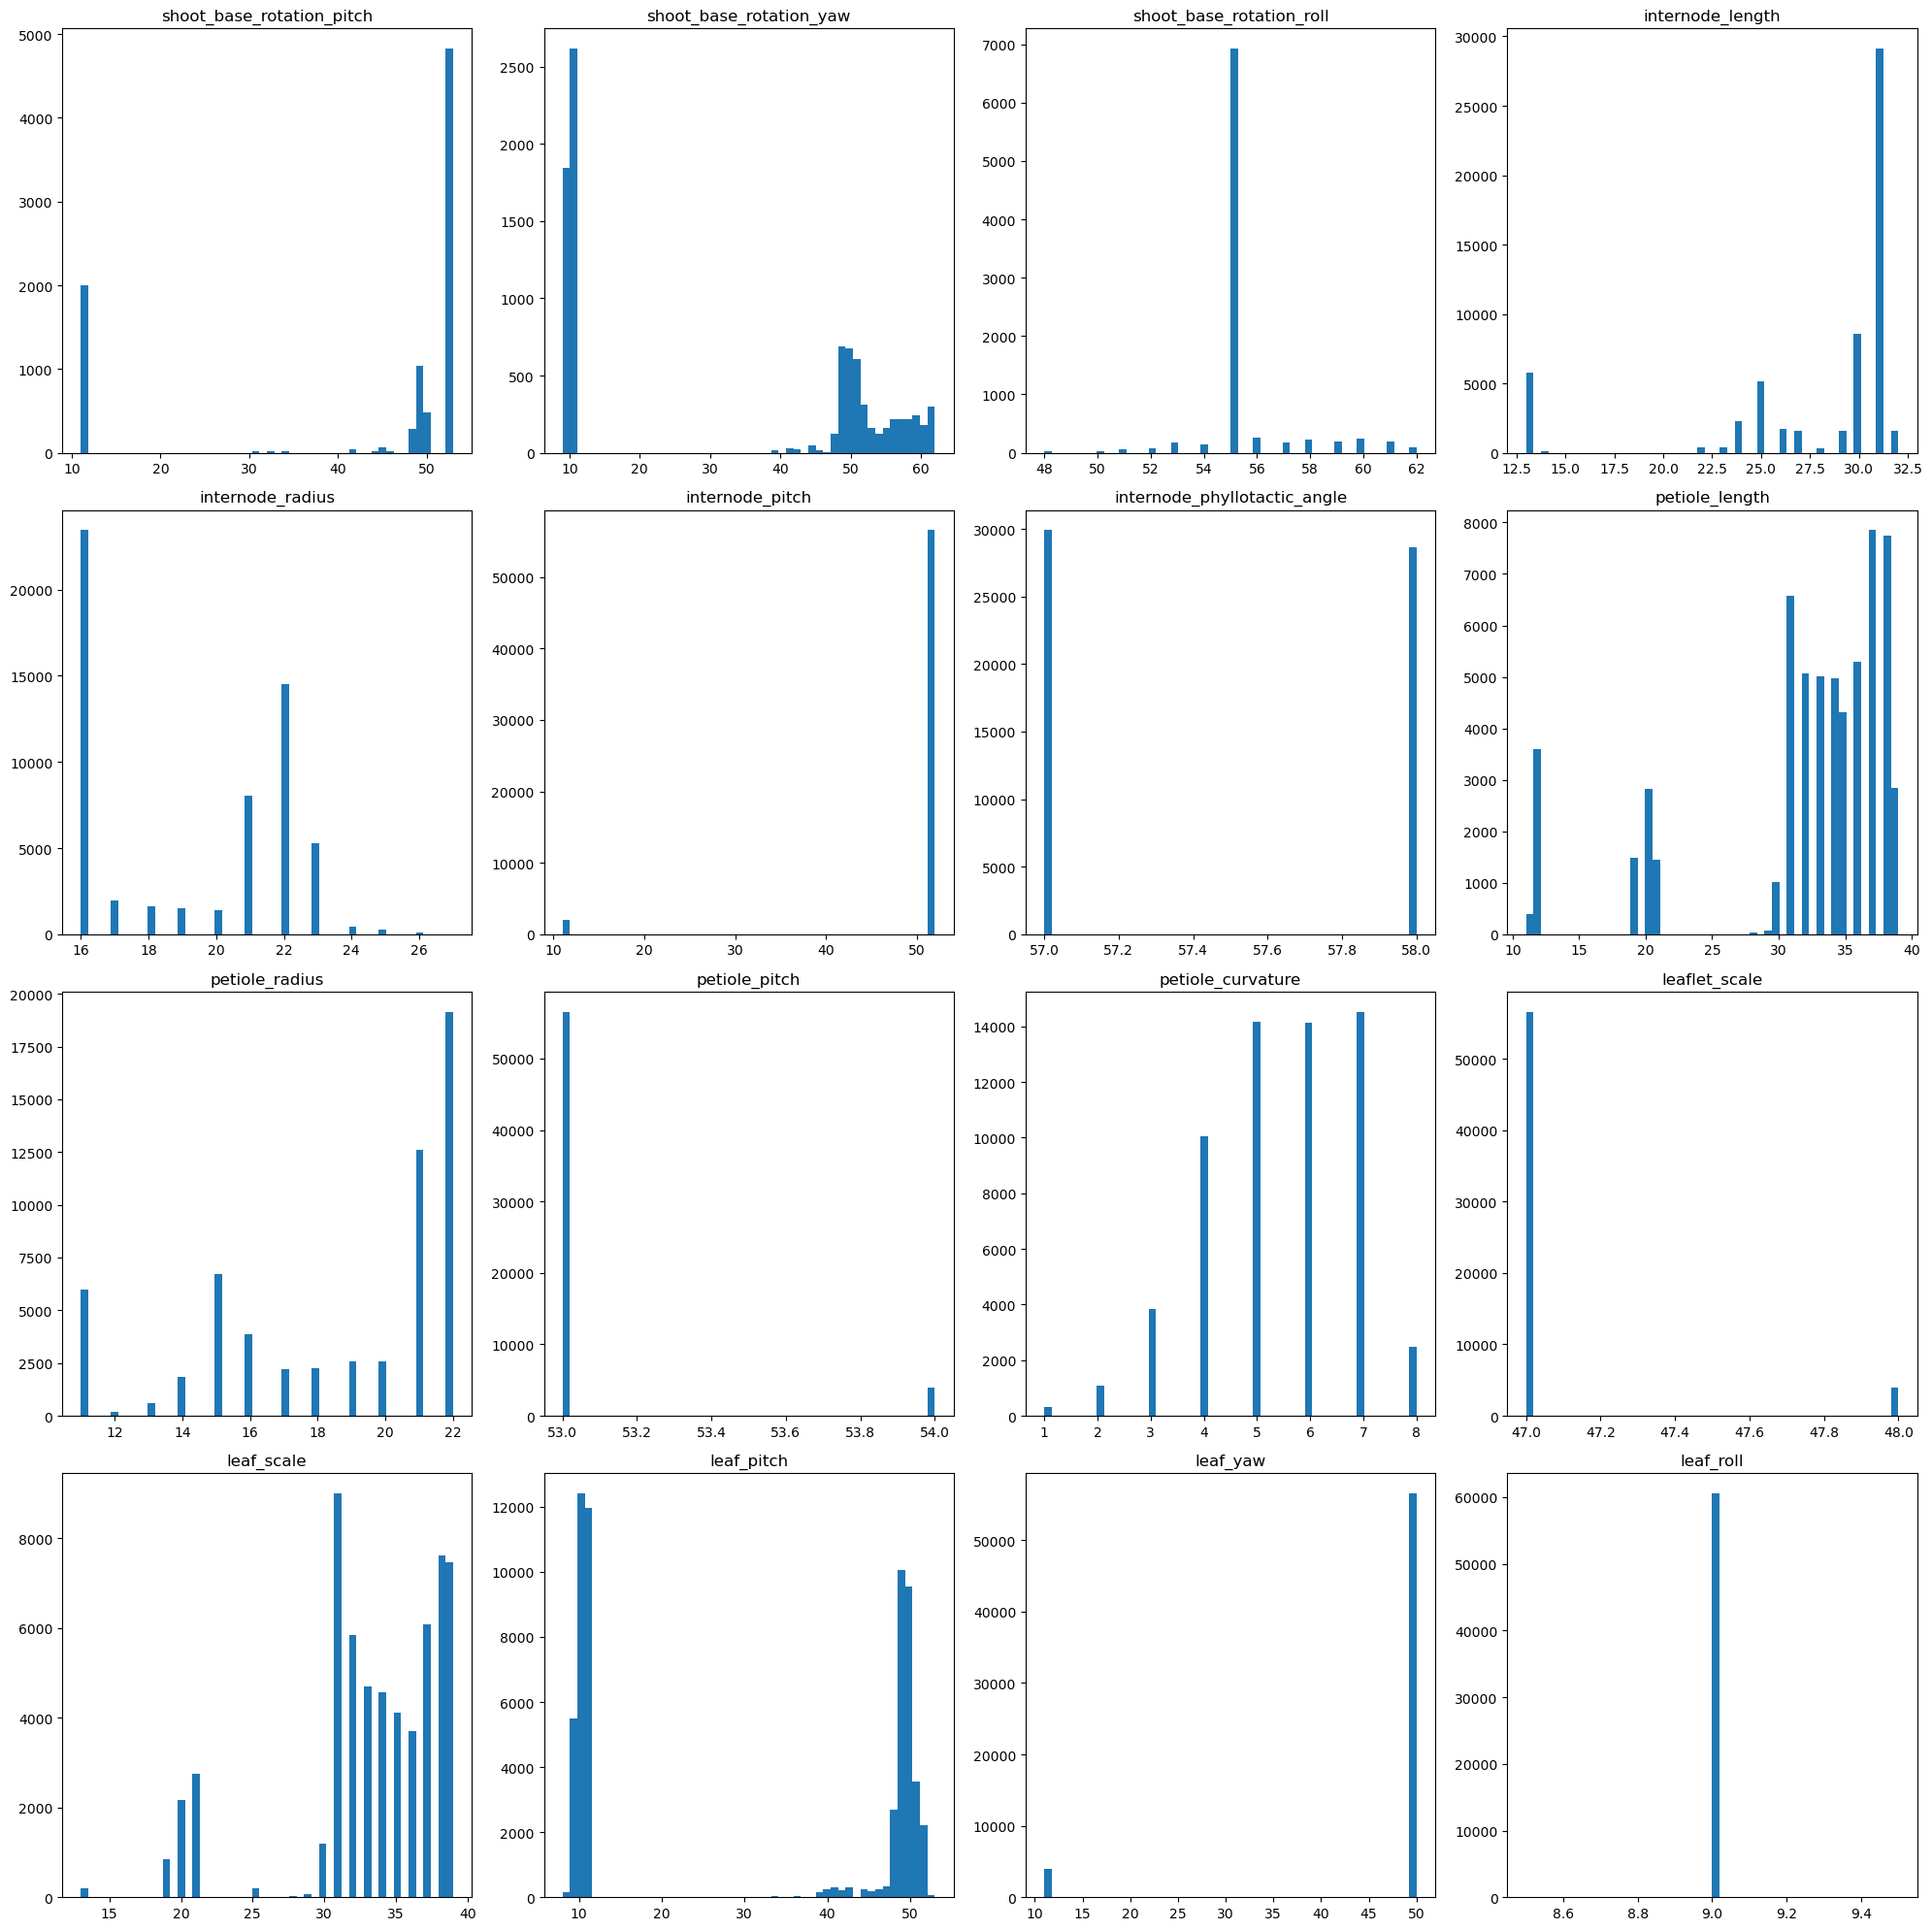

In [21]:
# Extract parameters
quantized_shoot_params = quantized_shoot_params.reshape(all_shoot_params.shape)
quantized_internode_params = quantized_internode_params.reshape(all_internode_params.shape)
quantized_petiole_params = quantized_petiole_params.reshape(all_petiole_params.shape)
quantized_leaf_params = quantized_leaf_params.reshape(all_leaf_params.shape)

shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = quantized_shoot_params[:, 0], quantized_shoot_params[:, 1], quantized_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = quantized_internode_params[:, 0], quantized_internode_params[:, 1], quantized_internode_params[:, 2], quantized_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = quantized_petiole_params[:, 0], quantized_petiole_params[:, 1], quantized_petiole_params[:, 2], quantized_petiole_params[:, 3], quantized_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = quantized_leaf_params[:, 0], quantized_leaf_params[:, 1], quantized_leaf_params[:, 2], quantized_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

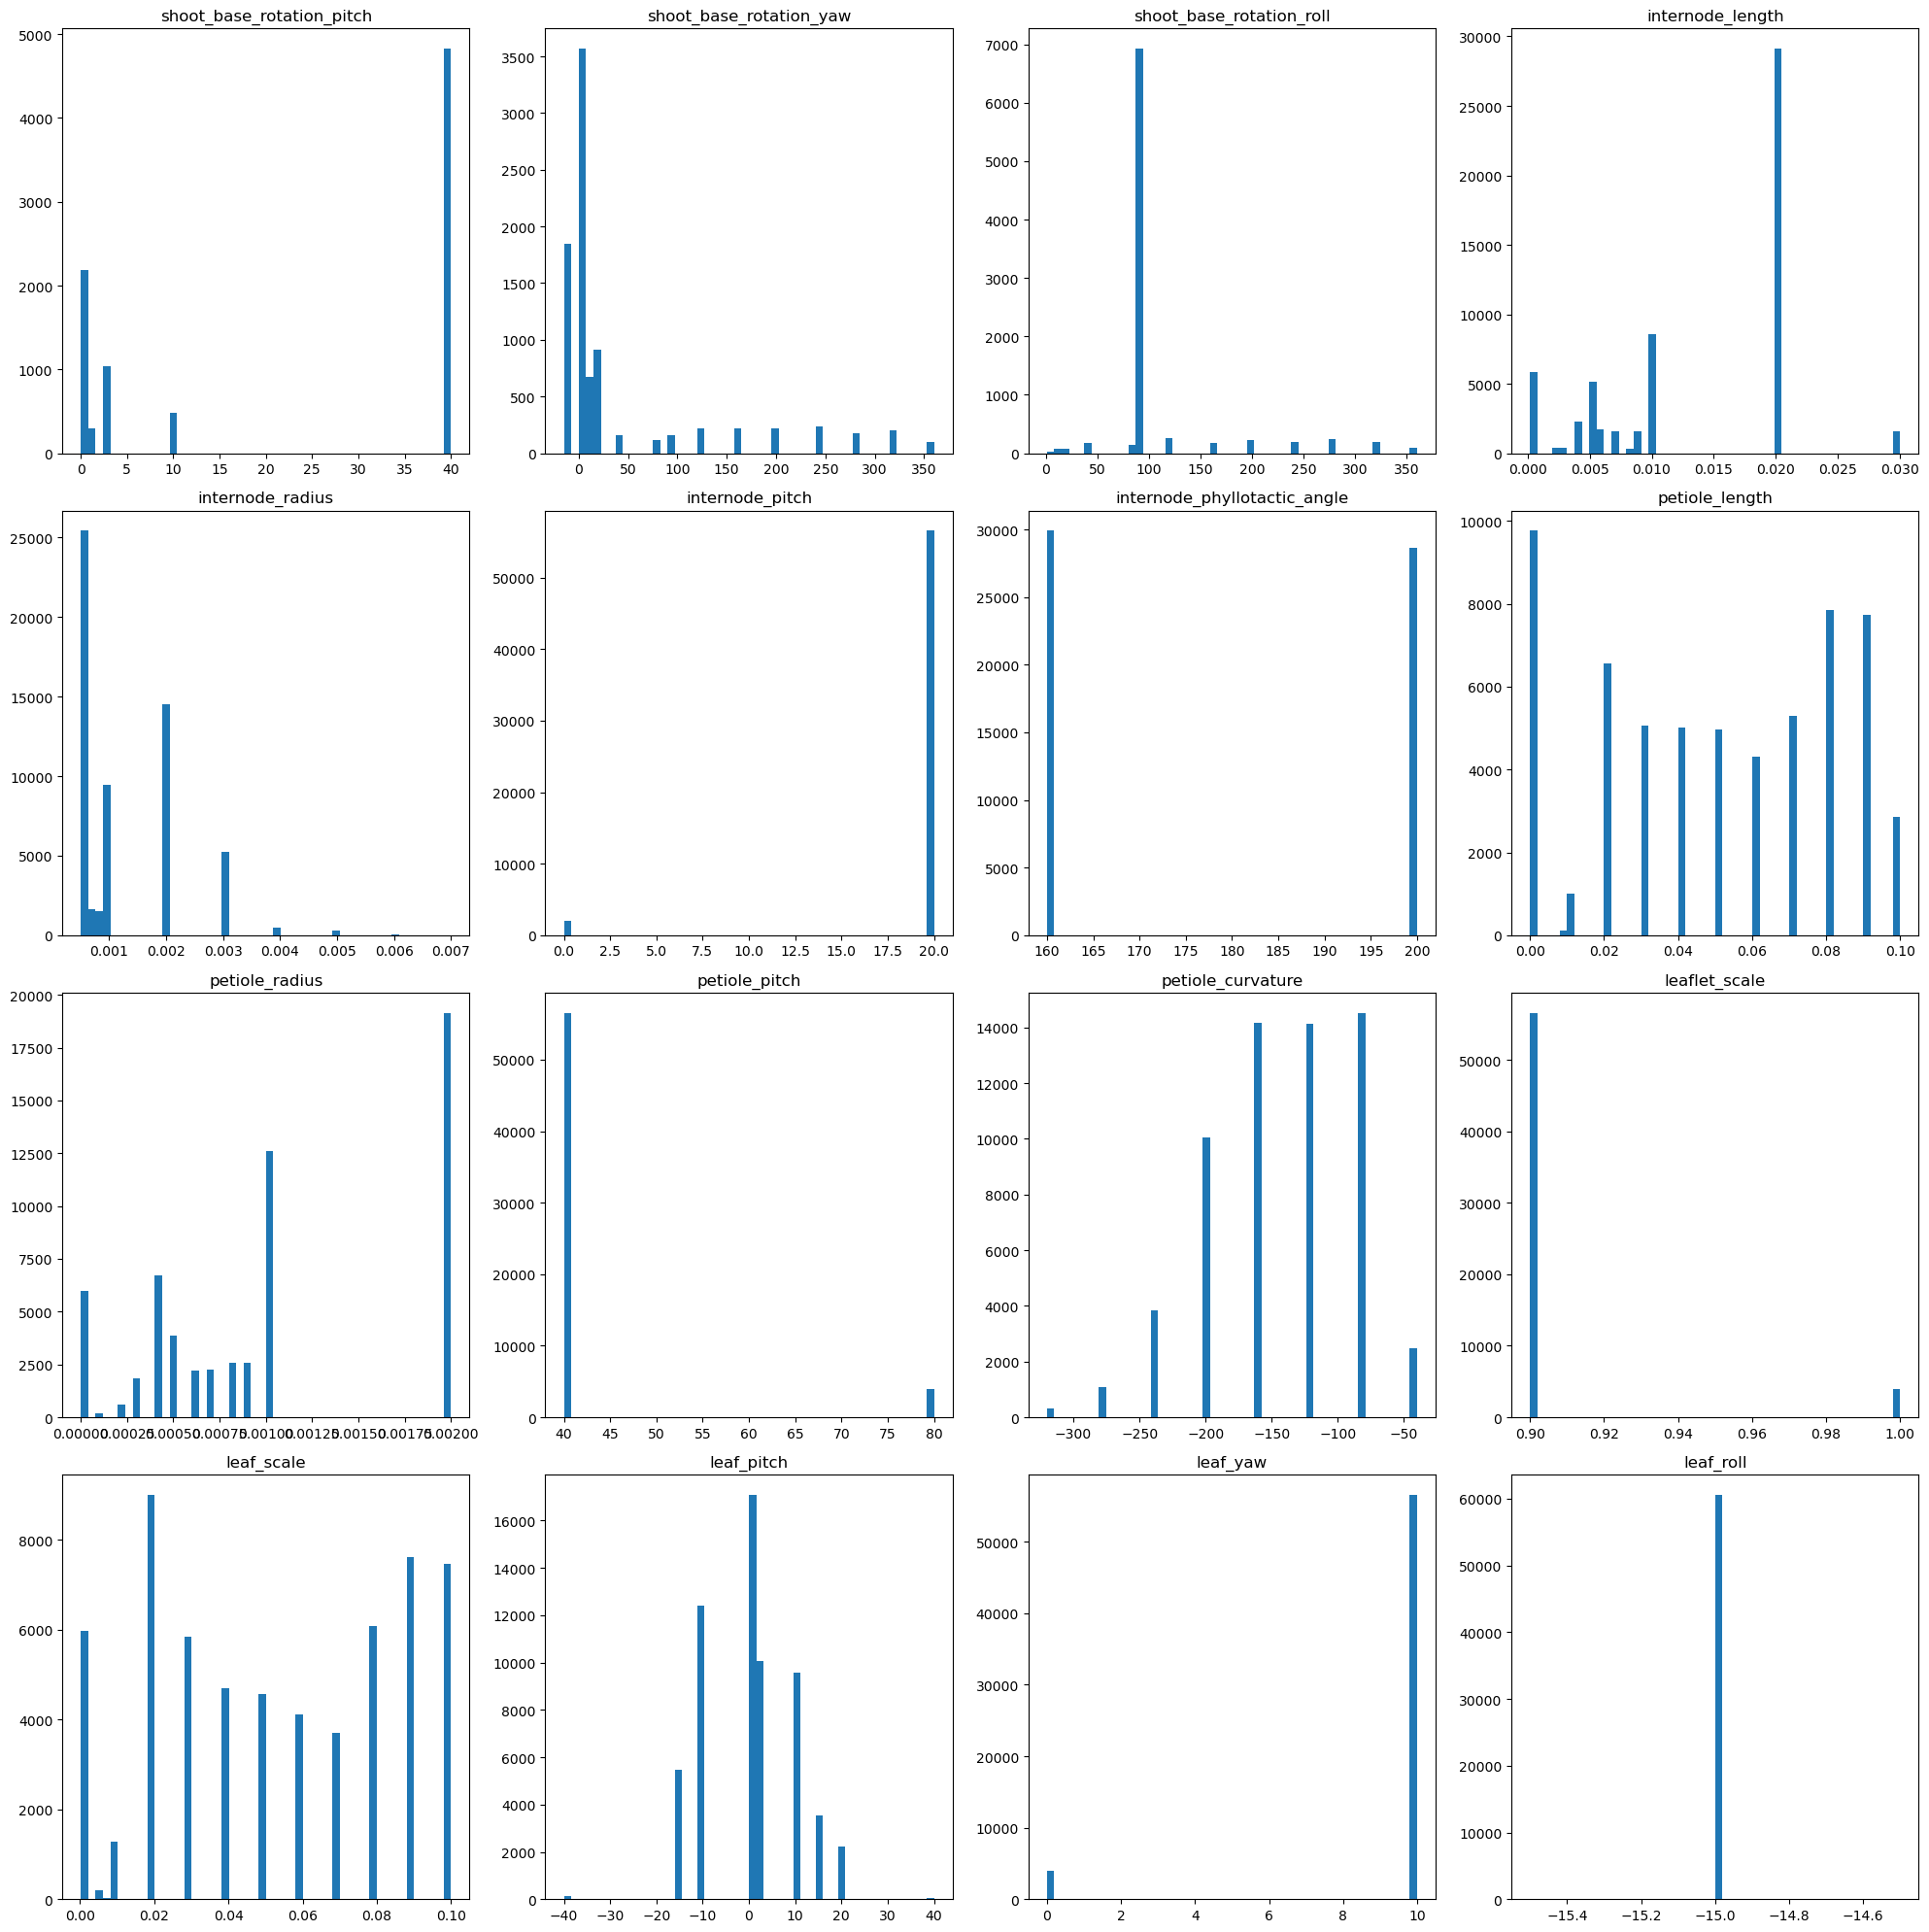

In [22]:
# Extract parameters
original_shoot_params = original_shoot_params.reshape(all_shoot_params.shape)
original_internode_params = original_internode_params.reshape(all_internode_params.shape)
original_petiole_params = original_petiole_params.reshape(all_petiole_params.shape)
original_leaf_params = original_leaf_params.reshape(all_leaf_params.shape)

shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = original_shoot_params[:, 0], original_shoot_params[:, 1], original_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = original_internode_params[:, 0], original_internode_params[:, 1], original_internode_params[:, 2], original_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = original_petiole_params[:, 0], original_petiole_params[:, 1], original_petiole_params[:, 2], original_petiole_params[:, 3], original_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = original_leaf_params[:, 0], original_leaf_params[:, 1], original_leaf_params[:, 2], original_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [33]:
class ParamQuantizer():
    def __init__(self):
        # Define predetermined centers using numpy
        predetermined_centers = np.unique(np.concatenate([
            np.array([0, 10, -10, 15, -15, 20, 40, 90]),  # Some special angles
            np.linspace(-360, 360, 18+1),  # angles
            np.array([0.9, 1.0]),  # Some special float values
            np.array([1, 3]),  # Some special integer values
            np.linspace(0, 1.0, 11),
            np.linspace(0, 0.1, 11),
            np.linspace(0, 0.01, 11),  # float values for lengths
            np.linspace(0, 0.001, 11)  # float values for lengths
        ])).reshape(-1, 1)

        # Convert numpy array to torch tensor
        self.predetermined_centers = torch.tensor(predetermined_centers, dtype=torch.float32)

    def transform(self, x):
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32)
        x_flatten = x.reshape(-1, 1)
        distances = torch.cdist(x_flatten, self.predetermined_centers)
        quantized = torch.argmin(distances, dim=1).reshape(x.shape)
        return quantized

    def inverse_transform(self, x):
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.int64)
        x_flatten = x.reshape(-1, 1).to(torch.int64)
        recovered = self.predetermined_centers[x_flatten].reshape(x.shape)
        return recovered

In [34]:
# Calculate the quantized params
quantizer = ParamQuantizer()
quantized_shoot_params = quantizer.transform(all_shoot_params.reshape(-1, 1))
quantized_internode_params = quantizer.transform(all_internode_params.reshape(-1, 1))
quantized_petiole_params = quantizer.transform(all_petiole_params.reshape(-1, 1))
quantized_leaf_params = quantizer.transform(all_leaf_params.reshape(-1, 1))

# Convert back to original params
original_shoot_params = quantizer.inverse_transform(quantized_shoot_params).reshape(all_shoot_params.shape)
original_internode_params = quantizer.inverse_transform(quantized_internode_params).reshape(all_internode_params.shape)
original_petiole_params = quantizer.inverse_transform(quantized_petiole_params).reshape(all_petiole_params.shape)
original_leaf_params = quantizer.inverse_transform(quantized_leaf_params).reshape(all_leaf_params.shape)

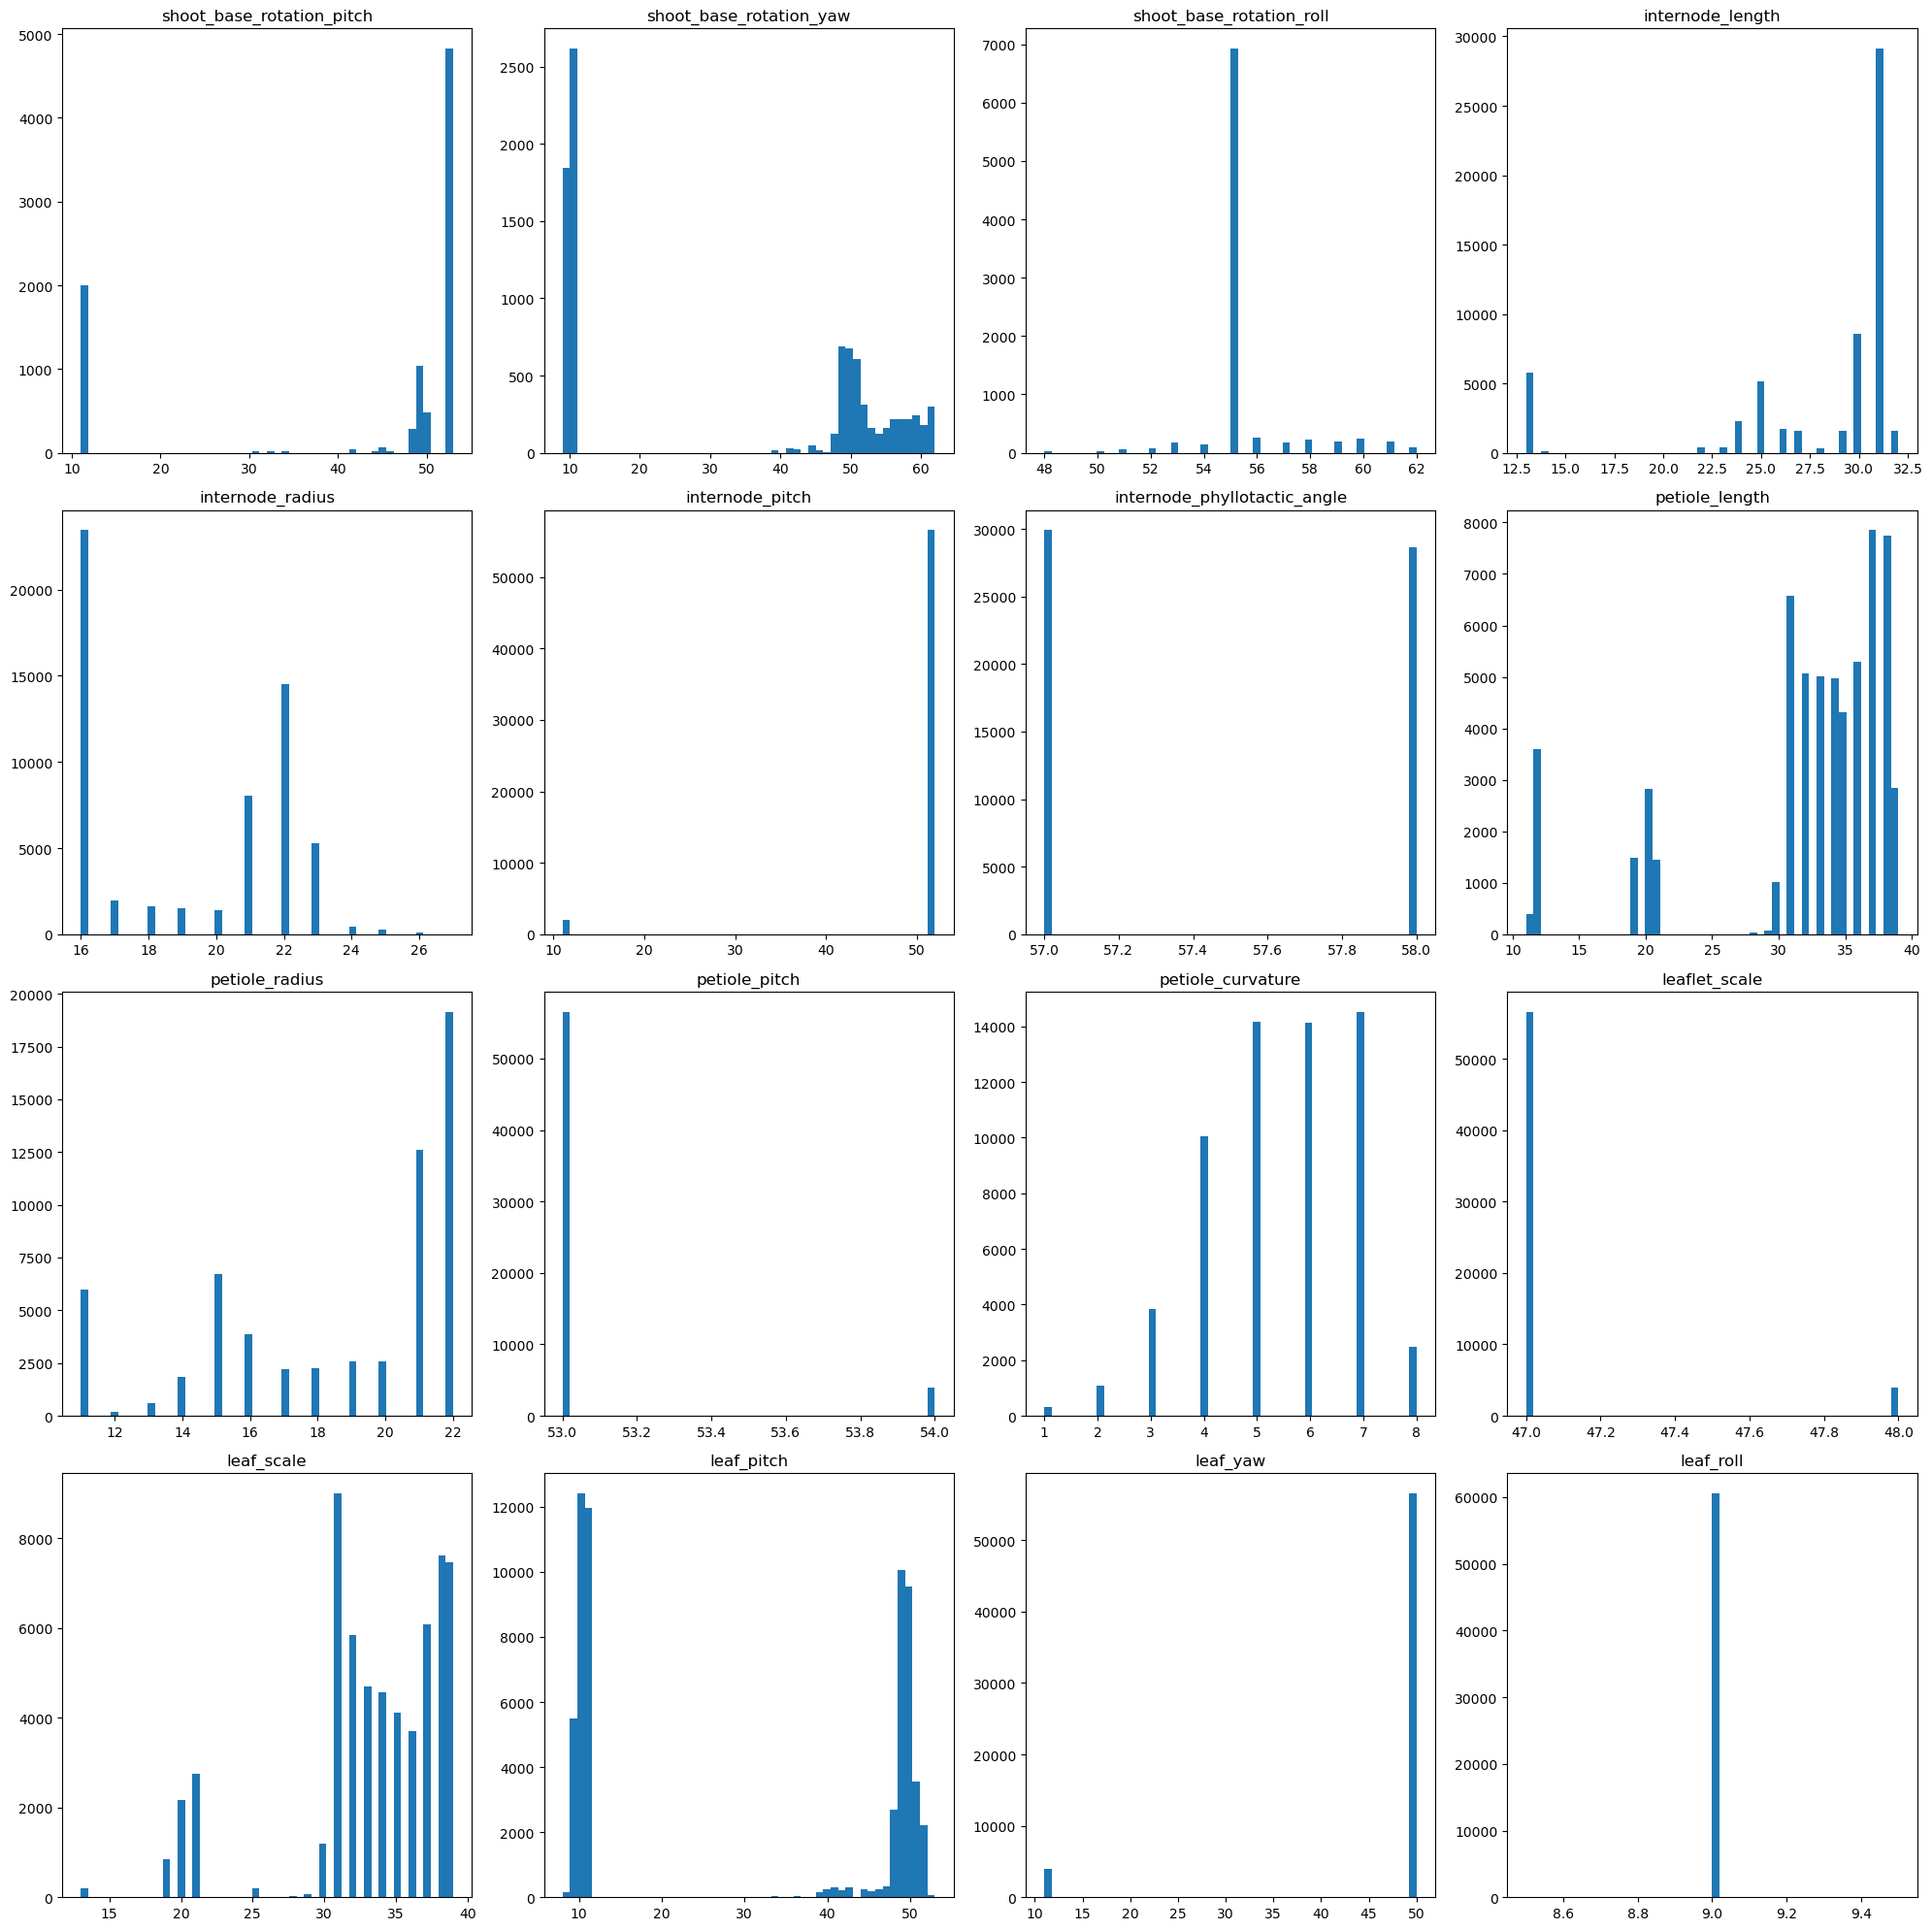

In [35]:
# Extract parameters
quantized_shoot_params = quantized_shoot_params.reshape(all_shoot_params.shape)
quantized_internode_params = quantized_internode_params.reshape(all_internode_params.shape)
quantized_petiole_params = quantized_petiole_params.reshape(all_petiole_params.shape)
quantized_leaf_params = quantized_leaf_params.reshape(all_leaf_params.shape)

shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = quantized_shoot_params[:, 0], quantized_shoot_params[:, 1], quantized_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = quantized_internode_params[:, 0], quantized_internode_params[:, 1], quantized_internode_params[:, 2], quantized_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = quantized_petiole_params[:, 0], quantized_petiole_params[:, 1], quantized_petiole_params[:, 2], quantized_petiole_params[:, 3], quantized_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = quantized_leaf_params[:, 0], quantized_leaf_params[:, 1], quantized_leaf_params[:, 2], quantized_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

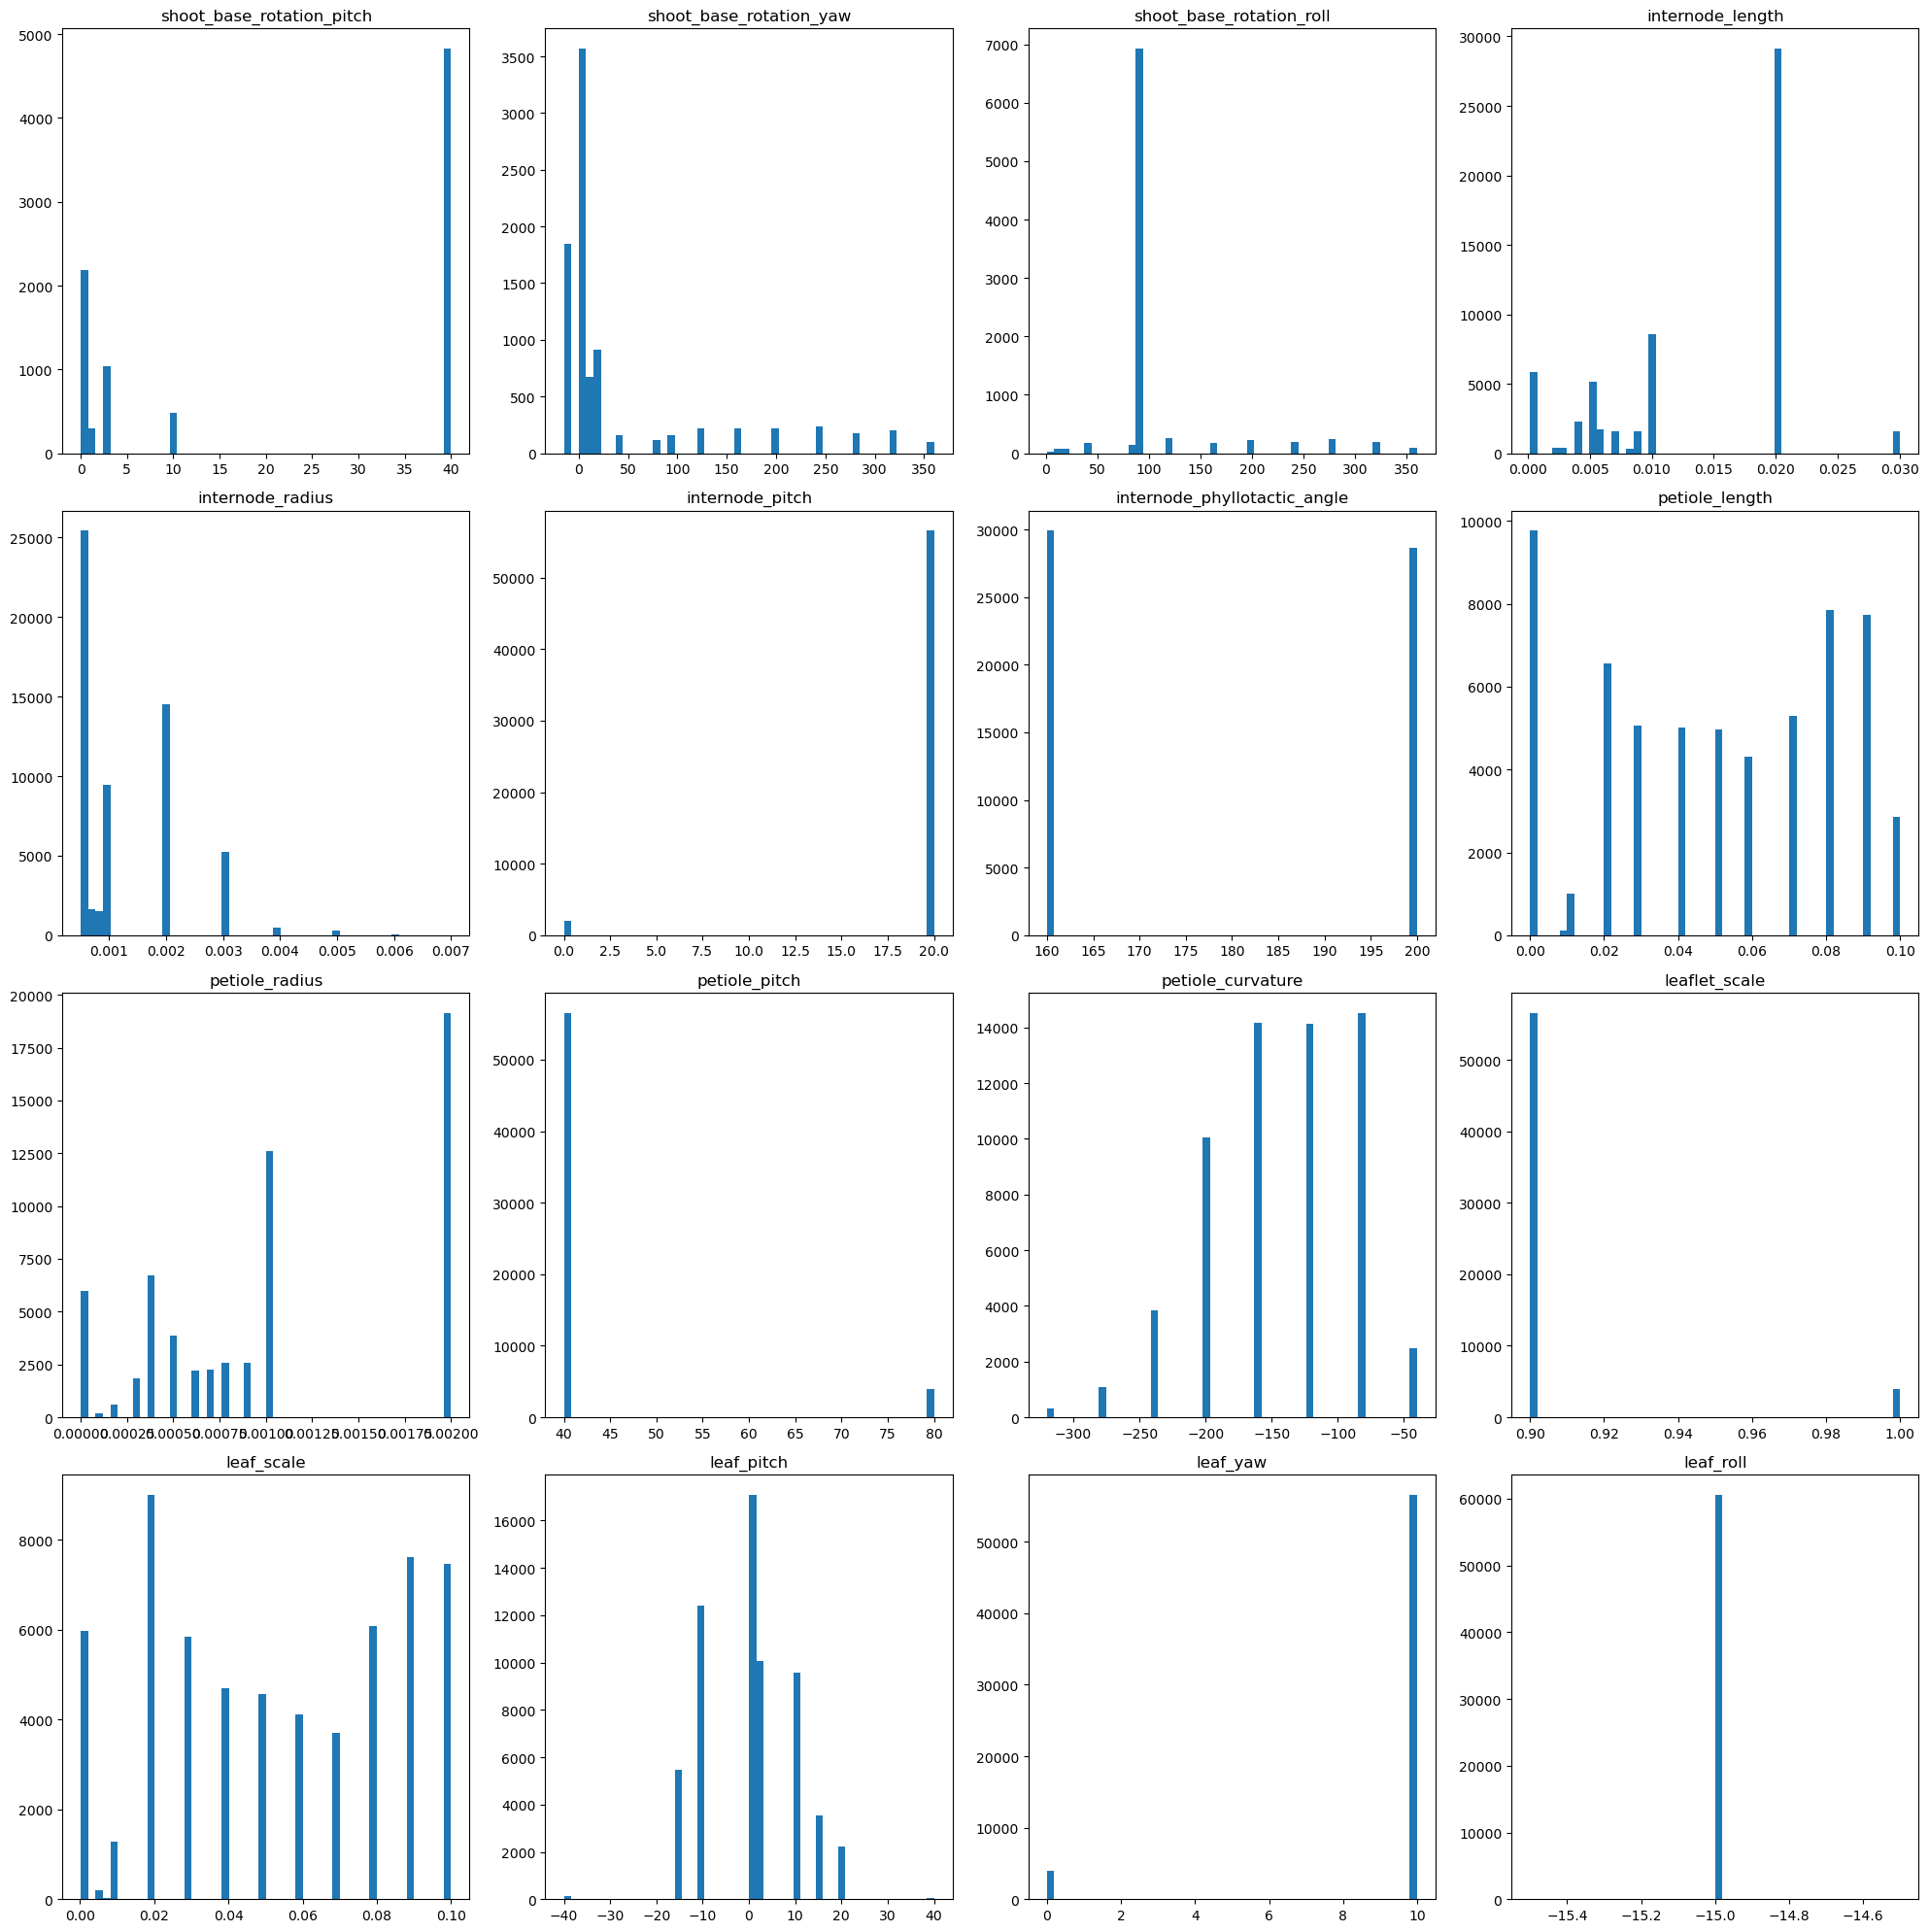

In [36]:
# Extract parameters
original_shoot_params = original_shoot_params.reshape(all_shoot_params.shape)
original_internode_params = original_internode_params.reshape(all_internode_params.shape)
original_petiole_params = original_petiole_params.reshape(all_petiole_params.shape)
original_leaf_params = original_leaf_params.reshape(all_leaf_params.shape)

shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = original_shoot_params[:, 0], original_shoot_params[:, 1], original_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = original_internode_params[:, 0], original_internode_params[:, 1], original_internode_params[:, 2], original_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = original_petiole_params[:, 0], original_petiole_params[:, 1], original_petiole_params[:, 2], original_petiole_params[:, 3], original_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = original_leaf_params[:, 0], original_leaf_params[:, 1], original_leaf_params[:, 2], original_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [37]:
# Add ../ as a directory to import from
import sys
sys.path.append('../')

# Test if the quantizing params have a significant impacto on the HELIOS rendering
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_vec_padded, SOS_token, EOS_token
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked
from plant_tokenizer import token2vec
import subprocess
import shutil
from models.plightning import MainDataModule
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import joblib


dataset_dir = "../data/Sideview_Dec23_2024"
datamodule = MainDataModule(dataset_dir,
                            image_size=224,
                            load_depth=False,
                            train_batch_size=1, num_workers=0, process_leaf=True, preload=False, side_view=True)
# growth_stages = [f"{day:02d}" for day in range(0,2)]
# datamodule.setup(growth_stages=growth_stages)
datamodule.setup()
if 1:
    dataloader = datamodule.test_dataloader()
    #dataloader = datamodule.val_dataloader()
else:
    dataloader = datamodule.train_dataloader()

program_path = "../src/GenerateDataset/build"

# Function to re-render a single XML file
def re_render_xml(output_path, filename, rotation=True):
    image_name = filename.split("/")[-1].split(".")[0]
    os.environ["DISPLAY"] = ":12.0"
    #os.environ["DISPLAY"] = ":1.0"
    # Generate image 
    # Construct the command
    command = ""
    command += f"cd {program_path} && ./main " 
    command += f"-h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    return result

# Prepare the figure
n_figures = 5
fig, axes = plt.subplots(2, n_figures, figsize=(20, 8))

# Create temp folder
temp_folder = "temp"
shutil.rmtree(temp_folder, ignore_errors=True)
os.makedirs(temp_folder, exist_ok=True)

image_size = 224
# Process and display 10 images
for idx, (image, plant_info, out, lengths) in enumerate(dataloader):
    if idx >= n_figures:
        break
    
    if image.dim() == 3:
        image = image.unsqueeze(0)
    ground_truth = out.squeeze(0).cpu().numpy()

    # Unscale it 
    scaler = dataloader.dataset.scaler
    ground_truth[:,1:] = scaler.inverse_transform(ground_truth[:,1:])
    plant_vec = token2vec(ground_truth)
    plant_xml = vec2xml(plant_vec, debug=True)
    plant_xml_file_name = f"temp/plant_{idx}_gt.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
    img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), image_size, True)

        
    image_vis = image[0].permute(1, 2, 0).cpu()

    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    row, col = divmod(idx, n_figures)
    axes[row, col].imshow(image_vis[:, :, 0:3])
    axes[row, col].set_title(f"Original Model {idx + 1}")
    axes[row, col].axis('off')

    axes[row + 1, col].imshow(img)
    axes[row + 1, col].set_title(f"Quantized Model {idx + 1}")
    axes[row + 1, col].axis('off')

plt.tight_layout()
plt.show()

Total 1000 images and plant strings loaded


AttributeError: 'ParamQuantizer' object has no attribute 'predetermined_centers'